In [373]:
#### [AI-CONTEXT]
#### ID: 001
#### ROLE: Import CSV file, extracted from https://www.blackrock.com/.
#### INPUT: User starting the application.
#### OUTPUT: Import the file iShareList.csv from the Google Drive and load it to the code the Google Colab notebook.


#### Dataset format: The spreadsheet has 487 rows, and each row is a iShare.
#### Dataset format: The first column 'TICKER' holds the ETF' tickers.
#### Dataset format: The second column 'FUND_NAME' holds the ETF' names.
#### Dataset format: The third column 'AUM' holds the total equity of each ETF.
#### Dataset format: The fourth column 'EXPENSE_RATIO' carries the annual fee deducted directly from the investment return.
#### Dataset format: The fifth column 'SEGMENT' refers to how the investment funds are categorized based on the underlying assets, industries, or investment strategies they track.
#### Dataset format: The last 90 columns are the last 90 workday market prices.

import pandas as pd

# IMPORTANT: Replace this with the actual public CSV export URL from your Google Sheet.
# Go to File > Share > Publish to web, select CSV format, and copy the generated URL.
google_sheet_url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vR2lDRyLftwO000SqNr7PFxHbFQfBcXLO8SVf1iIWl5YAXj2HkydpyaiOqCeEb-h8A7lJiC6RNyxbC5/pub?gid=2038189977&single=true&output=csv'

try:
    df = pd.read_csv(google_sheet_url)
    print("DataFrame loaded successfully!")
    print(f"Dataframe shape is {df.shape}") # ==> Dataframe shape is (487, 95)
except Exception as e:
    print(f"An error occurred: {e}")


DataFrame loaded successfully!
Dataframe shape is (487, 95)


In [374]:
#### [AI-CONTEXT]
#### ID: 002
#### ROLE: '#N/A' cleanse.
#### INPUT: Complete data import in the previous cell (successful execution of ID: 001).
#### OUTPUT: Coerce string data conversion into float numbers, and then replace nan values with the closest float value on the right.


import pandas as pd
import numpy as np

# Track the last 61 columns explicitly
target_cols = df.columns[-90:]

# Step 1: Clean raw string characters ('N/A', '#N/A', empty strings, whitespaces) across target columns
df[target_cols] = df[target_cols].replace(['N/A', '#N/A', '', r'^\s*$'], np.nan, regex=True)

# NEW STEP: Replace comma decimal separators with periods
# Apply this only to the columns that are intended to be numeric after cleaning
for col in target_cols:
    # Only apply if the column contains objects (strings) which might have commas
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)

# Step 2: FORCE a hard conversion of the data type from string ('str') to float ('float64')
# Using a dictionary mapping via .astype() completely breaks the strict 'str' schema lock
type_mapping = {col: 'float64' for col in target_cols}
df = df.astype(type_mapping)

# =====================================================================
# CUSTOM LOOKBACK FILLING ENGINE (LAST COLUMN SPECIAL CLAUSE)
# =====================================================================
# Target the final column name explicitly matching your 90-day absolute price timeline
last_col_name = df.columns[-1]

# Check if there are any missing cells in yesterday's close/target day before running operations
if df[last_col_name].isna().any():
    # 1. Isolate the target columns slice and reverse the chronological column order (Right-to-Left)
    # This places yesterday's close at index 0, day 89 at index 1, day 88 at index 2, etc.
    reversed_timeline_df = df[target_cols].iloc[:, ::-1]

    # 2. Apply a standard backward-fill across the reversed columns axis
    # Because the columns are flipped, axis=1 'bfill' now scans backwards through time (Right-to-Left)
    # until it hits the closest valid numeric price cell, skipping consecutive NaNs automatically!
    bfilled_reversed_df = reversed_timeline_df.bfill(axis=1)

    # 3. Flip the database columns back to their original chronological timeline order (Left-to-Right)
    restored_timeline_df = bfilled_reversed_df.iloc[:, ::-1]

    # 4. Extract only the freshly filled final column vector and update your primary dataframe
    # This applies the sequential fallback filling logic STRICTLY to the last column, leaving others untouched!
    df[last_col_name] = restored_timeline_df[last_col_name]

# Ensure the last column is cleanly rounded to 2 decimal places after the lookup filling operation
df[last_col_name] = df[last_col_name].round(2)

# Step 3: Replace NaNs with the valid float to their right, moving backwards
df[target_cols] = df[target_cols].bfill(axis=1)

# NEW STEP: Ensure the last column is rounded to 2 decimal places after all filling operations
df[last_col_name] = df[last_col_name].round(2)

# Step 4: Drop rows where ALL values in the last 61 columns are NaN
df = df.dropna(subset=target_cols, how='all')

In [375]:
#### [AI-CONTEXT]
#### ID: 003
#### ROLE: Implement data cleanup to improve memory efficiency.
#### INPUT: Completing the 'N/A' cleanse in the previous cell (successful execution of ID: 002).
#### OUTPUT: Free up space used to allocate the huge_df dataframe.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.

import gc

# 1. Delete the reference to the old dataframe
del target_cols, reversed_timeline_df, bfilled_reversed_df, restored_timeline_df, last_col_name

# 2. Force Python to collect the 'garbage' and release the RAM
gc.collect()

7338

In [376]:
#### [AI-CONTEXT]
#### ID: 004
#### ROLE: Preparation for the tokenization process.
#### INPUT: Complete memory wiping in the previous cell (successful execution of ID: 003)
#### OUTPUT: Load the HuggingFace Access Token in the notebook, by retrieving the HF_TOKEN API key indicated in the file named ".env".


import os
from google.colab import userdata
from huggingface_hub import login, whoami

# 1. Retrieve the HF_TOKEN from Colab secrets
api_key = userdata.get('HF_TOKEN')

# 2. Log in and Verify
if api_key:
    try:
        # Perform programmatic login
        login(token=api_key)

        # Verify the identity of the logged-in user
        user_info = whoami()
        username = user_info.get("Andre Soares", "andre-alss")

        print(f"✅ Successfully logged into Hugging Face as: {username}\n")
    except Exception as e:
        print(f"❌ Login failed: {str(e)}\n")
else:
    print("⚠️ Warning: HF_TOKEN not found in .env file.\n")

✅ Successfully logged into Hugging Face as: andre-alss



In [377]:
#### [AI-CONTEXT]
#### ID: 005
#### ROLE: Tokenization process for the NPL Branch.
#### INPUT: Successfully load the HuggingFace Access Token in the previous cell (successful execution of ID: 004).
#### OUTPUT: Encode the strings related to significant ETF details in preparation for an NLP Branch of a future Multilayer Perceptron (MLP).


from transformers import AutoTokenizer

# FinBERT is a pre-trained NLP model to analyze sentiment of financial text
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
# encoder ==> tokenizer(text, padding=True, truncation=True, return_tensors="pt")
# decoder ==> tokenizer.decode(encoded_input['input_ids'], skip_special_tokens=True)

input_str1 = tokenizer(df['TICKER'].astype(str).fillna("").tolist(),
                       padding=True, truncation=True, return_tensors="pt")

input_str2 = tokenizer(df['FUND_NAME'].astype(str).fillna("").tolist(),
                       padding=True, truncation=True, return_tensors="pt")

input_str3 = tokenizer(df['SEGMENT'].astype(str).fillna("").tolist(),
                       padding=True, truncation=True, return_tensors="pt")

In [378]:
#### [AI-CONTEXT]
#### ID: 006
#### ROLE: Vectorization process for the NPL Branch.
#### INPUT: Successfully encode the fund details in the previous cell (successful execution of ID: 005).
#### OUTPUT: The Detail tensor that will feed a NLP Branch of the future Multilayer Perceptron (MLP).


import torch
from transformers import BatchEncoding

# =====================================================================
# 1. ISOLATE INPUT IDS AND PREEMPT TYPE TRANSITIONS
# =====================================================================
# Process input_str1
if isinstance(input_str1, BatchEncoding):
    input_ids_str1 = input_str1['input_ids']
elif isinstance(input_str1, torch.Tensor):
    input_ids_str1 = input_str1
else:
    raise TypeError("input_str1 is invalid. Please re-run tokenization cell (ID: 005).")

# Process input_str2
if isinstance(input_str2, BatchEncoding):
    input_ids_str2 = input_str2['input_ids']
elif isinstance(input_str2, torch.Tensor):
    input_ids_str2 = input_str2
else:
    raise TypeError("input_str2 is invalid. Please re-run tokenization cell (ID: 005).")

# Process input_str3
if isinstance(input_str3, BatchEncoding):
    input_ids_str3 = input_str3['input_ids']
elif isinstance(input_str3, torch.Tensor):
    input_ids_str3 = input_str3
else:
    raise TypeError("input_str3 is invalid. Please re-run tokenization cell (ID: 005).")

# =====================================================================
# 2. CONCATENATE TEXT COLUMNS INTO THE GLOBAL INPUT TENSOR
# =====================================================================
# Use dim=1 to stack token arrays horizontally as feature columns
# NOTE: This requires all columns to have identical padding lengths from ID:005!
details_input_tensor = torch.cat([input_ids_str1, input_ids_str2, input_ids_str3], dim=1)
details_length = int(details_input_tensor.shape[1])

# =====================================================================
# 3. FIX: IMPLEMENT CHRONOLOGICAL SEQUENTIAL 80/20 MATRIX SPLIT
# =====================================================================
# Calculate the exact row index dividing the first 80% from the trailing 20%
total_rows = details_input_tensor.shape[0]
split_idx = int(total_rows * 0.8)

# Slice the matrix chronologically without shuffling or using random_state configurations
details_input_train_tensor = details_input_tensor[:split_idx, :].clone()
details_input_eval_tensor = details_input_tensor[split_idx:, :].clone()

# =====================================================================
# VERIFICATION AND DIAGNOSTIC LOG PANEL
# =====================================================================
print("=" * 75)
print("📋 CHRONOLOGICAL DATA SPLIT COMPLETELY INJECTED INTO TEXT VECTORIZATION")
print("=" * 75)
print(f"   • Total Combined Token Sequence Length: {details_length} features")
print(f"   • Global Text Footprint Row Count     : {total_rows} assets")
print("-" * 75)
print(f"   🚀 Training Split Matrix (First 80%)  : {list(details_input_train_tensor.shape)} -> details_input_train_tensor")
print(f"   🔮 Evaluation Split Matrix (Last 20%) : {list(details_input_eval_tensor.shape)} -> details_input_eval_tensor")
print("=" * 75)

📋 CHRONOLOGICAL DATA SPLIT COMPLETELY INJECTED INTO TEXT VECTORIZATION
   • Total Combined Token Sequence Length: 51 features
   • Global Text Footprint Row Count     : 487 assets
---------------------------------------------------------------------------
   🚀 Training Split Matrix (First 80%)  : [389, 51] -> details_input_train_tensor
   🔮 Evaluation Split Matrix (Last 20%) : [98, 51] -> details_input_eval_tensor


In [379]:
#### [AI-CONTEXT]
#### ID: 007
#### ROLE: Implement data cleanup to make the script memory efficient.
#### INPUT: Complete vectorization process for the NPL Branch in the previous cell (successful execution of ID: 006).
#### OUTPUT: Free up space used to allocate the input strings.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.

import gc

# Delete the temporary string collections, unpartitioned ID vectors, and global token array
del input_str1, input_str2, input_str3, input_ids_str1, input_ids_str2, input_ids_str3

# Force Python to release the freed memory blocks back to the system
gc.collect()

print("✅ [MEMORY CLEANUP ID: 007 COMPLETADO SUCCESSO]")
print("   • Raw text sequences and global unpartitioned token matrices flushed from RAM.")
print("   • Memory footprint fully optimized before tabular branch engineering blocks.")


✅ [MEMORY CLEANUP ID: 007 COMPLETADO SUCCESSO]
   • Raw text sequences and global unpartitioned token matrices flushed from RAM.
   • Memory footprint fully optimized before tabular branch engineering blocks.


In [380]:
#### [AI-CONTEXT]
#### ID: 008
#### ROLE: Vectorization process for the Tabular Branch.
#### INPUT: Complete the cleanup in the previous cell (successful execution of ID: 007).
#### OUTPUT: The Tax tensor that will feed a Tabular Branch of the future Multilayer Perceptron (MLP).


import torch
import numpy as np
import pandas as pd

# Turning the redemption/settlement period column into a safe two-dimensional tensor with float inputs.

if 'df' in globals():
    # 1. Select the settlement period column cleanly
    tax_df = df[['EXPENSE_RATIO']].copy()

    # 2. Strip the % sign, convert to float, and round to 2 decimal places
    tax_df['EXPENSE_RATIO'] = tax_df['EXPENSE_RATIO'].str.rstrip('%').astype(float).round(2)

    # 3. Convert to a structured 2D NumPy array with float32 representations
    numpy_array1 = tax_df.to_numpy().astype(np.float32).reshape(-1, 1)

    # 4. Convert the NumPy array to a PyTorch tensor
    tax_input_tensor = torch.from_numpy(numpy_array1)

    # 5. CROSS-BRANCH ALIGNMENT DIAGNOSTIC REPORTING
    success_tab = (
        f"✅ Sucesso: Processo de vetorização da ramificação tabular concluído!\n"
        f"   • Tax Tensor Shape (2D)         : {list(tax_input_tensor.shape)}\n"
    )
    print(success_tab)

    # Dynamic cross-check validation if companion model branch structures exist in memory context
    if 'details_input_tensor' in globals() and 'tax_input_tensor' in globals():
        nlp_samples = details_input_tensor.shape[0]
        tab1_samples = tax_input_tensor.shape[0]

        print("-" * 75)
        print(f"📊 Verificação de Alinhamento das Ramificações do Modelo (Tamanho do Lote):")
        print(f"   • Ramificação NLP (Details Tensor)     : {nlp_samples} amostras")
        print(f"   • Ramificação Tabular (Tax Tensor)     : {tab1_samples} amostras")
        print("-" * 75)
else:
    print("❌ Erro de Sequência: 'df' indisponível na memória.")

✅ Sucesso: Processo de vetorização da ramificação tabular concluído!
   • Tax Tensor Shape (2D)         : [487, 1]

---------------------------------------------------------------------------
📊 Verificação de Alinhamento das Ramificações do Modelo (Tamanho do Lote):
   • Ramificação NLP (Details Tensor)     : 487 amostras
   • Ramificação Tabular (Tax Tensor)     : 487 amostras
---------------------------------------------------------------------------


In [381]:
#### [AI-CONTEXT]
#### ID: 009
#### ROLE: Implement data cleanup to make the script memory efficient.
#### INPUT: Complete vectorization of the tax column for the Tabular Branch in the previous cell (successful execution of ID: 008).
#### OUTPUT: Free up space used to allocate the input strings.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.

import gc

del tax_df, numpy_array1
gc.collect()

19

In [382]:
#### [AI-CONTEXT]
#### ID: 010
#### ROLE: Vectorization process for the Tabular Branch.
#### INPUT: Complete the cleanup in the previous cell (successful execution of ID: 009).
#### OUTPUT: The Equity tensor that will feed a Tabular Branch of the future Multilayer Perceptron (MLP).


import torch
import numpy as np
import pandas as pd

# Turning the redemption/settlement period column into a safe two-dimensional tensor with float inputs.

if 'df' in globals():
    # 1. Select the settlement period column cleanly
    equity_df = df[['AUM']].copy()

    # 2. Extract the numerical values as floats by removing symbols
    numeric_part = equity_df['AUM'].str.replace(r'[\$BM]', '', regex=True).astype(float)

    # 3. Extract the suffix multiplier map (B -> 1B, M -> 1M, otherwise 1)
    multipliers = equity_df['AUM'].str.extract(r'([BM])')[0].map({'B': 1e9, 'M': 1e6}).fillna(1)

    # 4. Multiply and round
    equity_df['AUM'] = (numeric_part * multipliers).round(2)

    # 5. Convert to a structured 2D NumPy array with float32 representations
    numpy_array2 = equity_df.to_numpy().astype(np.float32).reshape(-1, 1)

    # 6. Convert the NumPy array to a PyTorch tensor
    equity_input_tensor = torch.from_numpy(numpy_array2)

    # 7. CROSS-BRANCH ALIGNMENT DIAGNOSTIC REPORTING
    success_tab = (
        f"✅ Sucesso: Processo de vetorização da ramificação tabular concluído!\n"
        f"   • Equity Tensor Shape (2D)     : {list(equity_input_tensor.shape)}\n"
    )
    print(success_tab)

    # Dynamic cross-check validation if companion model branch structures exist in memory context
    if 'details_input_tensor' in globals() and 'equity_input_tensor' in globals():
        nlp_samples = details_input_tensor.shape[0]
        tab1_samples = tax_input_tensor.shape[0]
        tab2_samples = equity_input_tensor.shape[0]

        print("-" * 75)
        print(f"📊 Verificação de Alinhamento das Ramificações do Modelo (Tamanho do Lote):")
        print(f"   • Ramificação NLP (Details Tensor)     : {nlp_samples} amostras")
        print(f"   • Ramificação Tabular (Tax Tensor)     : {tab1_samples} amostras")
        print(f"   • Ramificação Tabular (Equity Tensor)  : {tab2_samples} amostras")
        print("-" * 75)
else:
    print("❌ Erro de Sequência: 'df' indisponível na memória.")

✅ Sucesso: Processo de vetorização da ramificação tabular concluído!
   • Equity Tensor Shape (2D)     : [487, 1]

---------------------------------------------------------------------------
📊 Verificação de Alinhamento das Ramificações do Modelo (Tamanho do Lote):
   • Ramificação NLP (Details Tensor)     : 487 amostras
   • Ramificação Tabular (Tax Tensor)     : 487 amostras
   • Ramificação Tabular (Equity Tensor)  : 487 amostras
---------------------------------------------------------------------------


In [383]:
#### [AI-CONTEXT]
#### ID: 011
#### ROLE: Implement data cleanup to make the script memory efficient.
#### INPUT: Complete vectorization of the equity column for the Tabular Branch in the previous cell (successful execution of ID: 010).
#### OUTPUT: Free up space used to allocate the input strings.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.

import gc

del equity_df, numpy_array2
gc.collect()

18

In [384]:
#### [AI-CONTEXT]
#### ID: 012
#### ROLE: Training/Evaluation split and StandardScaler normalization of the equity column for the Tabular Branch of the MLP.
#### INPUT: Complete the cleanup in the previous cell (successful execution of ID: 011).
#### OUTPUT: equity_std_input_train_tensor and equity_std_input_eval_tensor.


import torch
import numpy as np
from sklearn.preprocessing import StandardScaler

if 'equity_input_tensor' in globals():

    # =====================================================================
    # 1. FIX: CHRONOLOGICAL SEQUENTIAL 80/20 SPLIT MATRICES (NO SHUFFLING)
    # =====================================================================
    # Replicates the exact sequential row boundaries applied to your text branch
    total_rows = equity_input_tensor.shape[0]
    split_idx = int(total_rows * 0.8)

    # Slice the raw tensor array sequentially along the cross-sectional index path
    equity_input_train_tensor = equity_input_tensor[:split_idx, :].clone()
    equity_input_eval_tensor = equity_input_tensor[split_idx:, :].clone()

    # 2. Initialize the required statistical scaling transformers
    equity_scaler = StandardScaler()

    # 3. Convert tensors to CPU NumPy arrays for Scikit-Learn compatibility
    equity_train_np = equity_input_train_tensor.cpu().numpy()
    equity_eval_np = equity_input_eval_tensor.cpu().numpy()

    # 4. Fit and transform metrics using StandardScaler (Train data ONLY to prevent leakage)
    scaled_equity_train_np = equity_scaler.fit_transform(equity_train_np)
    scaled_equity_eval_np = equity_scaler.transform(equity_eval_np)

    # 5. Convert back to PyTorch 2D float tensors
    equity_std_input_train_tensor = torch.from_numpy(scaled_equity_train_np).float()
    equity_std_input_eval_tensor = torch.from_numpy(scaled_equity_eval_np).float()

    # --- LOCALIZED SANDBOX REPORTING LOGS ---
    print("📊 VALORES EXTREMOS ORIGINAIS (Tensores Brutos):")
    print("-" * 75)
    print(f"   • Equity Train Tensor | Mín: {equity_input_train_tensor.min().item():.2f} | Máx: {equity_input_train_tensor.max().item():.2f} | Méd: {equity_input_train_tensor.mean().item():.2f}")
    print(f"   • Equity Eval Tensor  | Mín: {equity_input_eval_tensor.min().item():.2f} | Máx: {equity_input_eval_tensor.max().item():.2f} | Méd: {equity_input_eval_tensor.mean().item():.2f}\n")
    print("x" * 75)
    print("✨ VALORES NORMALIZADOS FINAIS (Prontos para Ingestão):\n")
    print("-" * 75)
    print(f"   • Scaled Equity Train Tensor  | Mín: {equity_std_input_train_tensor.min().item():.2f} | Máx: {equity_std_input_train_tensor.max().item():.2f}  | Méd: {equity_std_input_train_tensor.mean().item():.2f} <--- StandardScaler")
    print(f"   • Scaled Equity Eval Tensor   | Mín: {equity_std_input_eval_tensor.min().item():.2f} | Máx: {equity_std_input_eval_tensor.max().item():.2f} | Méd: {equity_std_input_eval_tensor.mean().item():.2f} <--- StandardScaler")
    print("-" * 75)
    print(f"📊 DIAGNÓSTICO DE DIMENSÕES DE TENSORES EM MODO SEQUENCIAL:")
    print(f"   • Formato Final do Tensor Equity Train (2D): {list(equity_std_input_train_tensor.shape)}")
    print(f"   • Formato Final do Tensor Equity Eval (2D): {list(equity_std_input_eval_tensor.shape)}")
    print("-" * 75)
else:
    print("❌ Erro de Sequência: Tensores de entrada não localizados na memória.")

📊 VALORES EXTREMOS ORIGINAIS (Tensores Brutos):
---------------------------------------------------------------------------
   • Equity Train Tensor | Mín: 3460000.00 | Máx: 851399999488.00 | Méd: 9920108544.00
   • Equity Eval Tensor  | Mín: 6670000.00 | Máx: 93220003840.00 | Méd: 6914321408.00

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
✨ VALORES NORMALIZADOS FINAIS (Prontos para Ingestão):

---------------------------------------------------------------------------
   • Scaled Equity Train Tensor  | Mín: -0.21 | Máx: 17.62  | Méd: 0.00 <--- StandardScaler
   • Scaled Equity Eval Tensor   | Mín: -0.21 | Máx: 1.74 | Méd: -0.06 <--- StandardScaler
---------------------------------------------------------------------------
📊 DIAGNÓSTICO DE DIMENSÕES DE TENSORES EM MODO SEQUENCIAL:
   • Formato Final do Tensor Equity Train (2D): [389, 1]
   • Formato Final do Tensor Equity Eval (2D): [98, 1]
----------------------------------------------------------------

In [385]:
#### [AI-CONTEXT]
#### ID: 013
#### ROLE: Implement data cleanup to make the script memory efficient.
#### INPUT: Complete train/eval split and normalization of the equity column (successful execution of ID: 012).
#### OUTPUT: Free up space used to allocate the input strings.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.

import gc

del equity_input_train_tensor, equity_input_eval_tensor, equity_train_np, equity_eval_np, scaled_equity_train_np, scaled_equity_eval_np
gc.collect()

0

In [386]:
#### [AI-CONTEXT]
#### ID: 014
#### ROLE: Training/Evaluation split and StandardScaler normalization of the equity column for the Tabular Branch of the MLP.
#### INPUT: Complete the cleanup in the previous cell (successful execution of ID: 013).
#### OUTPUT: tax_std_input_train_tensor and tax_std_input_eval_tensor.


import torch
import numpy as np
from sklearn.preprocessing import StandardScaler

if 'tax_input_tensor' in globals():

    # =====================================================================
    # 1. FIX: CHRONOLOGICAL SEQUENTIAL 80/20 SPLIT MATRICES (NO SHUFFLING)
    # =====================================================================
    # Replicates the exact sequential row boundaries applied across your data layers
    total_rows = tax_input_tensor.shape[0]
    split_idx = int(total_rows * 0.8)

    # Slice the raw tensor array sequentially along the cross-sectional index path
    tax_input_train_tensor = tax_input_tensor[:split_idx, :].clone()
    tax_input_eval_tensor = tax_input_tensor[split_idx:, :].clone()

    # 2. Initialize the statistical scaling transformer
    tax_scaler = StandardScaler()

    # 3. Convert tensors to CPU NumPy arrays for Scikit-Learn compatibility
    tax_train_np = tax_input_train_tensor.cpu().numpy()
    tax_eval_np = tax_input_eval_tensor.cpu().numpy()

    # 4. Fit and transform the feature column independently (Train data ONLY to prevent leakage)
    # Mandated negative inversion distribution multiplier remains fully preserved
    scaled_tax_train_np = -tax_scaler.fit_transform(tax_train_np)
    scaled_tax_eval_np = -tax_scaler.transform(tax_eval_np)

    # 5. Convert back to PyTorch 2D float tensors
    tax_std_input_train_tensor = torch.from_numpy(scaled_tax_train_np).float()
    tax_std_input_eval_tensor = torch.from_numpy(scaled_tax_eval_np).float()

    # --- LOCALIZED SANDBOX REPORTING LOGS ---
    print("📊 VALORES EXTREMOS ORIGINAIS (Tensores Brutos):")
    print("-" * 75)
    print(f"   • Tax Train Tensor | Mín: {tax_input_train_tensor.min().item():.2f} | Máx: {tax_input_train_tensor.max().item():.2f}  | Méd: {tax_input_train_tensor.mean().item():.2f}")
    print(f"   • Tax Eval Tensor  | Mín: {tax_input_eval_tensor.min().item():.2f} | Máx: {tax_input_eval_tensor.max().item():.2f}  | Méd: {tax_input_eval_tensor.mean().item():.2f}\n")
    print("x" * 75)
    print("✨ VALORES NORMALIZADOS FINAIS (Prontos para Ingestão):\n")
    print("-" * 75)
    print(f"   • Scaled Tax Train Tensor  | Mín: {tax_std_input_train_tensor.min().item():.2f} | Máx: {tax_std_input_train_tensor.max().item():.2f}  | Méd: {tax_std_input_train_tensor.mean().item():.2f} <--- StandardScaler (Inverted)")
    print(f"   • Scaled Tax Eval Tensor   | Mín: {tax_std_input_eval_tensor.min().item():.2f} | Máx: {tax_std_input_eval_tensor.max().item():.2f}  | Méd: {tax_std_input_eval_tensor.mean().item():.2f} <--- StandardScaler (Inverted)")
    print("-" * 75)
    print(f"📊 DIAGNÓSTICO DE DIMENSÕES DE TENSORES EM MODO SEQUENCIAL:")
    print(f"   • Formato Final do Tensor Tax Train (2D): {list(tax_std_input_train_tensor.shape)} (Expected: [389, 1])")
    print(f"   • Formato Final do Tensor Tax Eval (2D): {list(tax_std_input_eval_tensor.shape)} (Expected: [98, 1])")
    print("-" * 75)
else:
    print("❌ Erro de Sequência: Tensores de entrada não localizados na memória.")

📊 VALORES EXTREMOS ORIGINAIS (Tensores Brutos):
---------------------------------------------------------------------------
   • Tax Train Tensor | Mín: 0.03 | Máx: 0.99  | Méd: 0.30
   • Tax Eval Tensor  | Mín: 0.03 | Máx: 0.75  | Méd: 0.29

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
✨ VALORES NORMALIZADOS FINAIS (Prontos para Ingestão):

---------------------------------------------------------------------------
   • Scaled Tax Train Tensor  | Mín: -3.65 | Máx: 1.41  | Méd: 0.00 <--- StandardScaler (Inverted)
   • Scaled Tax Eval Tensor   | Mín: -2.39 | Máx: 1.41  | Méd: 0.03 <--- StandardScaler (Inverted)
---------------------------------------------------------------------------
📊 DIAGNÓSTICO DE DIMENSÕES DE TENSORES EM MODO SEQUENCIAL:
   • Formato Final do Tensor Tax Train (2D): [389, 1] (Expected: [389, 1])
   • Formato Final do Tensor Tax Eval (2D): [98, 1] (Expected: [98, 1])
---------------------------------------------------------------------

In [387]:
#### [AI-CONTEXT]
#### ID: 015
#### ROLE: Implement data cleanup to make the script memory efficient.
#### INPUT: Complete train/eval split and normalization of the tax column (successful execution of ID: 014).
#### OUTPUT: Free up space used to allocate the input strings.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.

import gc

del tax_input_train_tensor, tax_input_eval_tensor, tax_train_np, tax_eval_np, scaled_tax_train_np, scaled_tax_eval_np
gc.collect()

0

In [388]:
#### [AI-CONTEXT]
#### ID: 016
#### ROLE: Vectorization, train/eval sets split, and standardization for the Time-Series LSTM Branch.
#### INPUT: Complete the cleanup in the previous cell (successful execution of ID: 015).
#### OUTPUT: price_std_train_tensor, price_std_target_train_tensor, price_std_eval_tensor, price_std_target_eval_tensor, all normalized with row-wise local/iShare Standard Scaler.


import torch
import numpy as np

if 'df' in globals():
    # 1. Isolate values from the last 90 columns and force raw NumPy float64 mapping
    numpy_matrix = df.iloc[:, -90:].values.astype(np.float64)

    # =====================================================================
    # 2. CHRONOLOGICAL SEQUENTIAL 80/20 SPLIT MATRICES (NO SHUFFLING)
    # =====================================================================
    total_rows = numpy_matrix.shape[0]
    split_idx = int(total_rows * 0.8)

    train_np = numpy_matrix[:split_idx, :]
    eval_np = numpy_matrix[split_idx:, :]

    price_train_tensor = torch.tensor(train_np, dtype=torch.float32)
    price_eval_tensor = torch.tensor(eval_np, dtype=torch.float32)

    # =====================================================================
    # 3. SEPARATE FEATURES AND TARGETS BEFORE SCALING (TEMPORAL ISOLATION)
    # =====================================================================
    x_train_raw = price_train_tensor[:, :-1]
    y_train_raw = price_train_tensor[:, [-1]]

    x_eval_raw = price_eval_tensor[:, :-1]
    y_eval_raw = price_eval_tensor[:, [-1]]

    # =====================================================================
    # 4. COMPUTE LOCAL ROW-WISE SCALING PARAMETERS WITH SAFE CLAMPING
    # =====================================================================
    price_train_row_means = x_train_raw.mean(dim=1, keepdim=True)
    raw_train_stds = x_train_raw.std(dim=1, keepdim=True, unbiased=False)

    price_eval_row_means = x_eval_raw.mean(dim=1, keepdim=True)
    raw_eval_stds = x_eval_raw.std(dim=1, keepdim=True, unbiased=False)

    # FIXED: Clamp near-zero variances to 1.0 to neutralize the epsilon division spike!
    price_train_row_stds = torch.where(raw_train_stds < 1e-4, torch.ones_like(raw_train_stds), raw_train_stds)
    price_eval_row_stds = torch.where(raw_eval_stds < 1e-4, torch.ones_like(raw_eval_stds), raw_eval_stds)

    # =====================================================================
    # 5. EXECUTE LOCALIZED ROW-WISE STANDARD NORMALIZATION
    # =====================================================================
    price_std_train_tensor = (x_train_raw - price_train_row_means) / price_train_row_stds
    price_std_eval_tensor = (x_eval_raw - price_eval_row_means) / price_eval_row_stds

    price_std_target_train_tensor = (y_train_raw - price_train_row_means) / price_train_row_stds
    price_std_target_eval_tensor = (y_eval_raw - price_eval_row_means) / price_eval_row_stds

    print("📊 DIAGNÓSTICO DE PADRONIZAÇÃO LOCAL (ZERO-VARIANCE COMPLETADO):")
    print("-" * 85)
    print(f"   • Train Features Max Z: {price_std_train_tensor.max().item():.4f}")
    print(f"   • Train Targets Max Z : {price_std_target_train_tensor.max().item():.4f} (Deve estar entre ~3 e 5)")
    print(f"   • Eval Targets Max Z  : {price_std_target_eval_tensor.max().item():.4f} (Deve estar entre ~3 e 5)")
    print("-" * 85)
else:
    print("❌ Erro de Sequência: DataFrame 'df' não localizado na memória.")

📊 DIAGNÓSTICO DE PADRONIZAÇÃO LOCAL (ZERO-VARIANCE COMPLETADO):
-------------------------------------------------------------------------------------
   • Train Features Max Z: 3.3515
   • Train Targets Max Z : 2.7382 (Deve estar entre ~3 e 5)
   • Eval Targets Max Z  : 2.5792 (Deve estar entre ~3 e 5)
-------------------------------------------------------------------------------------


In [389]:
#### [AI-CONTEXT]
#### ID: 017
#### ROLE: Implement data cleanup to make the script memory efficient.
#### INPUT: Complete train/eval split and normalization of the price columns (successful execution of ID: 016).
#### OUTPUT: Free up space used to allocate the input strings.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.
# FIXED: Kept row-wise mean and std tracking vectors alive in memory for future De-Standardization scripts!

import gc

# Delete only the heavy raw arrays that are no longer structurally required
del numpy_matrix, price_train_tensor, price_eval_tensor

# Explicitly invoke Python's garbage collection routine
gc.collect()

print("✅ [MEMORY CLEANUP ID: 017 COMPLETADO SUCCESSO]")
print("   • Raw source price matrices flushed from RAM.")
print("   • Localized asset scale tracking vectors preserved for invertible mapping layer.")

✅ [MEMORY CLEANUP ID: 017 COMPLETADO SUCCESSO]
   • Raw source price matrices flushed from RAM.
   • Localized asset scale tracking vectors preserved for invertible mapping layer.


In [390]:
#### [AI-CONTEXT]
#### ID: 018
#### ROLE: Prepare a pile of finance benchmark tensors to be processed along with the scaled profit tensor in the Time-Series LSTM Branch.
#### INPUT: Complete the cleanup in the previous cell (successful execution of ID: 011).
#### OUTPUT: Fetch market data aligned strictly with the last 90 US business days. Create unnormalized benchmark tensors.


import torch
import numpy as np
import pandas as pd
import yfinance as yf

# 1. Expand indicators dictionary with explicit tracking channels
yahoo_indicators = {
    "GOLD": "GC=F", "NASDAQ": "^IXIC", "DAX": "^GDAXI", "DOWJONES": "^DJI",
    "S&P500": "^GSPC", "RUSSELL2000": "^RUT", "SHANGHAI": "000001.SS",
    "NIKKEI": "^N225", "EUROSTOXX": "^STOXX50E", "CAC": "^FCHI",
    "FTSE100": "^FTSE", "IBOV": "^BVSP", "HANG SENG": "^HSI",
    "ALL ORDS": "^AORD", "IDX": "^JKSE", "STI": "^STI",
    "KOSPI": "^KS11", "FTSE/JSE": "^JN0U.JO", "US3MO": "^IRX",
    "US2YT": "ZT=F", "US5YT": "^FVX", "US10YT": "^TNX",
    "BTC_USD": "BTC-USD", "WTI": "CL=F", "VIX": "^VIX",
    "BRENT": "BZ=F", "SILVER": "SI=F", "COPPER": "HG=F",
    "RINF": "RINF", "BCI": "BCI"
}

# 2. Establish the exact US business day skeleton from the S&P 500
anchor_ticker = "^GSPC"
us_market_df = yf.download(anchor_ticker, period="200d", progress=False, auto_adjust=True)

# FIX: Change slice boundary to -90 to capture the exact lookback horizon matching your stock layout
if isinstance(us_market_df.columns, pd.MultiIndex):
    us_business_days = us_market_df['Close'][anchor_ticker].dropna().index[-90:]
else:
    us_business_days = us_market_df['Close'].dropna().index[-90:]

aligned_data = {}

# 3. Pull and align Yahoo Finance indicators across the adjusted 90-day window
for name, ticker in yahoo_indicators.items():
    raw_df = yf.download(ticker, period="200d", progress=False, auto_adjust=True)

    if isinstance(raw_df.columns, pd.MultiIndex):
        close_series = raw_df['Close'][ticker]
    else:
        close_series = raw_df['Close']

    aligned_series = close_series.reindex(us_business_days).ffill().bfill()
    aligned_data[name] = aligned_series.values

# =====================================================================
# 4. HYBRID SCALING ENGINE & TIMELINE TRUNCATION LAYER (89-DAY ALIGNED)
# =====================================================================
normalized_indicator_tensors = {}
eps = 1e-6

# Explicitly divide the 30 assets by their structural financial properties
decimal_yield_group = ["US3MO", "US2YT", "US5YT", "US10YT", "VIX"]
absolute_price_group = [col for col in yahoo_indicators.keys() if col not in decimal_yield_group]

for name, raw_array in aligned_data.items():
    arr_f32 = raw_array.astype(np.float32)

    # --- Step A: Base Transformation ---
    if name in decimal_yield_group:
        transformed_series = arr_f32 / 100.0
    else:
        transformed_series = arr_f32

    # --- Step B: Extract Training Window (Compresses 90 days down to 89) ---
    # FIX: Truncating the final element isolates the target day to match your 89-day lookback features matrix!
    feature_window_series = transformed_series[:-1]

    # --- Step C: Apply Z-Score Equalization and Symmetrical Clipping ---
    series_mean = np.mean(feature_window_series)
    series_std = np.std(feature_window_series)

    equalized_series = (feature_window_series - series_mean) / (series_std + eps)
    clipped_series = np.clip(equalized_series, -3.5, 3.5)

    # Cast directly as clean PyTorch float32 arrays
    normalized_indicator_tensors[name] = torch.tensor(clipped_series, dtype=torch.float32)

# =====================================================================
# VERIFICATION PHASE
# =====================================================================
print(f"✅ Total Indicators Processed: {len(normalized_indicator_tensors)}")
print(f"✅ Target Sequence Length   : 89 Days (Perfect Match for 89-Day Price Features)")
print("="*95)
for name, tensor in normalized_indicator_tensors.items():
    print(f"Indicator: {name:<12} | Tensor Shape: {list(tensor.shape)} | Min: {tensor.min().item():.2f} | Max: {tensor.max().item():.2f}")
print("="*95)

✅ Total Indicators Processed: 30
✅ Target Sequence Length   : 89 Days (Perfect Match for 89-Day Price Features)
Indicator: GOLD         | Tensor Shape: [89] | Min: -2.43 | Max: 2.02
Indicator: NASDAQ       | Tensor Shape: [89] | Min: -1.77 | Max: 1.77
Indicator: DAX          | Tensor Shape: [89] | Min: -2.47 | Max: 1.44
Indicator: DOWJONES     | Tensor Shape: [89] | Min: -2.36 | Max: 1.75
Indicator: S&P500       | Tensor Shape: [89] | Min: -2.03 | Max: 1.75
Indicator: RUSSELL2000  | Tensor Shape: [89] | Min: -1.96 | Max: 1.65
Indicator: SHANGHAI     | Tensor Shape: [89] | Min: -3.02 | Max: 2.04
Indicator: NIKKEI       | Tensor Shape: [89] | Min: -1.73 | Max: 2.34
Indicator: EUROSTOXX    | Tensor Shape: [89] | Min: -2.37 | Max: 1.67
Indicator: CAC          | Tensor Shape: [89] | Min: -2.32 | Max: 2.35
Indicator: FTSE100      | Tensor Shape: [89] | Min: -2.56 | Max: 2.64
Indicator: IBOV         | Tensor Shape: [89] | Min: -2.04 | Max: 1.99
Indicator: HANG SENG    | Tensor Shape: [89] | M

In [391]:
#### [AI-CONTEXT]
#### ID: 019
#### ROLE: implement the 3D Master Tensor Layout logic for Train. It takes your standardized_tensor and the 30 indicators from normalized_indicator_tensors, scales them symmetrically, and stacks them into the final (389, 90, 31) tensor.
#### INPUT: price_std_train_tensor and rescaled_tensor.
#### OUTPUT: master_train_3d_tensor, master_input_train_3d_tensor.


import torch

# =====================================================================
# 3D MASTER TRAIN TENSOR LAYOUT CONSTRUCTION (89-DAY ALIGNED)
# =====================================================================

# Step 1: Initialize the feature list and establish the primary anchor (Feature 0)
# price_std_train_tensor shape expected: (389, 89) from row-wise engine ID:016
feature_train_layers = [price_std_train_tensor]

num_ishares = price_std_train_tensor.shape[0]
target_days = price_std_train_tensor.shape[1] # Programmatically captures exactly 89 lookback days

# Step 2: Loop through, broadcast, and align all 30 macro indicators
# Points directly to your 89-day dictionary compiled inside ID:018
for name, indicator_tensor in normalized_indicator_tensors.items():
    # Shape transition: (89,) -> (1, 89)
    unsqueezed_tensor = indicator_tensor.unsqueeze(0)

    # Shape transition: (1, 89) -> (389, 89)
    # Copies the macro timeline identically across all 389 synchronized iShare rows
    broadcasted_tensor = unsqueezed_tensor.expand(num_ishares, -1)

    # Append the aligned matrix to our feature list
    feature_train_layers.append(broadcasted_tensor)

# Step 3: Stack all 31 layers along the final depth dimension (dim=2)
# Compresses your independent arrays into a unified 3D tensor of shape: (389, 89, 31)
master_train_3d_tensor = torch.stack(feature_train_layers, dim=-1)

# This preserves your exact 89-day sequential lookup feature footprint perfectly.
master_input_train_3d_tensor = master_train_3d_tensor

# =====================================================================
# VERIFICATION PHASE
# =====================================================================
print("✅ [3D MASTER TRAIN TENSOR LAYOUT VERIFIED - ROW-WISE ALIGNED]")
print("=" * 75)
print(f"Master Train Tensor Shape: {master_input_train_3d_tensor.shape} (Expected: [389, 89, 31])")
print(f"Dimension 0 (iShares)     : {master_input_train_3d_tensor.shape[0]}")
print(f"Dimension 1 (Days)        : {master_input_train_3d_tensor.shape[1]} [Price Wave Steps]")
print(f"Dimension 2 (Features)    : {master_input_train_3d_tensor.shape[2]} channels")
print("-" * 75)

# Quick validation check on a single iShare's daily feature slice
sample_train_vector = master_input_train_3d_tensor[0, 0, :]
print(f"Sample Feature Vector (iShare 0, Day 0) Shape : {sample_train_vector.shape}")
print(f"Primary Anchor (iShare Price Wave) Value       : {sample_train_vector[0].item():.4f}")
print(f"First Macro Indicator (GOLD) Value             : {sample_train_vector[1].item():.4f}")
print("=" * 75)

✅ [3D MASTER TRAIN TENSOR LAYOUT VERIFIED - ROW-WISE ALIGNED]
Master Train Tensor Shape: torch.Size([389, 89, 31]) (Expected: [389, 89, 31])
Dimension 0 (iShares)     : 389
Dimension 1 (Days)        : 89 [Price Wave Steps]
Dimension 2 (Features)    : 31 channels
---------------------------------------------------------------------------
Sample Feature Vector (iShare 0, Day 0) Shape : torch.Size([31])
Primary Anchor (iShare Price Wave) Value       : -0.6395
First Macro Indicator (GOLD) Value             : 0.6405


In [392]:
#### [AI-CONTEXT]
#### ID: 020
#### ROLE: implement the 3D Master Tensor Layout logic for Eval. It takes your standardized_tensor and the 30 indicators from minmax_scaled_tensors, scales them symmetrically, and stacks them into the final (98, 90, 31) tensor.
#### INPUT: price_std_eval_tensor and rescaled_tensor.
#### OUTPUT: master_eval_3d_tensor, master_input_eval_3d_tensor.


import torch

# =====================================================================
# 3D MASTER EVAL TENSOR LAYOUT CONSTRUCTION (89-DAY ALIGNED)
# =====================================================================

# Step 1: Initialize the feature list and establish the primary anchor (Feature 0)
# price_std_eval_tensor shape expected: (98, 89)
feature_eval_layers = [price_std_eval_tensor]

num_ishares = price_std_eval_tensor.shape[0]
target_days = price_std_eval_tensor.shape[1] # Programmatically captures exactly 89 lookback days

# Step 2: Loop through, broadcast, and align all 30 macro indicators
# Points directly to your 89-day dictionary compiled inside ID:018
for name, indicator_tensor in normalized_indicator_tensors.items():
    # Shape transition: (89,) -> (1, 89)
    unsqueezed_tensor = indicator_tensor.unsqueeze(0)

    # Shape transition: (1, 89) -> (98, 89)
    # Copies the macro timeline identically across all 98 synchronized evaluation iShare rows
    broadcasted_tensor = unsqueezed_tensor.expand(num_ishares, -1)

    # Append the aligned matrix to our feature list
    feature_eval_layers.append(broadcasted_tensor)

# Step 3: Stack all 31 layers along the final depth dimension (dim=2)
# Compresses your independent arrays into a unified 3D evaluation tensor of shape: (98, 89, 31)
master_eval_3d_tensor = torch.stack(feature_eval_layers, dim=-1)

# FIX: Assigned directly since data leakage was completely resolved in data engines!
# This preserves your exact 89-day sequential evaluation feature footprint perfectly.
master_input_eval_3d_tensor = master_eval_3d_tensor

# =====================================================================
# VERIFICATION PHASE
# =====================================================================
print("✅ [3D MASTER EVAL TENSOR LAYOUT VERIFIED - 89-DAY MODE COMPLETE]")
print("=" * 75)
print(f"Master Input Eval Tensor Shape: {master_input_eval_3d_tensor.shape} (Expected: [98, 89, 31])")
print(f"Dimension 0 (iShares)          : {master_input_eval_3d_tensor.shape[0]}")
print(f"Dimension 1 (Days)             : {master_input_eval_3d_tensor.shape[1]} [Price Wave Steps]")
print(f"Dimension 2 (Features)         : {master_input_eval_3d_tensor.shape[2]} channels")
print("-" * 75)

# Quick validation check on a single iShare's daily feature slice
sample_eval_vector = master_input_eval_3d_tensor[0, 0, :]
print(f"Sample Feature Vector (iShare 0, Day 0) Shape : {sample_eval_vector.shape}")
print(f"Primary Anchor (iShare Price Wave) Value       : {sample_eval_vector[0].item():.4f}")
print(f"First Macro Indicator (GOLD) Value             : {sample_eval_vector[1].item():.4f}")
print("=" * 75)

✅ [3D MASTER EVAL TENSOR LAYOUT VERIFIED - 89-DAY MODE COMPLETE]
Master Input Eval Tensor Shape: torch.Size([98, 89, 31]) (Expected: [98, 89, 31])
Dimension 0 (iShares)          : 98
Dimension 1 (Days)             : 89 [Price Wave Steps]
Dimension 2 (Features)         : 31 channels
---------------------------------------------------------------------------
Sample Feature Vector (iShare 0, Day 0) Shape : torch.Size([31])
Primary Anchor (iShare Price Wave) Value       : 0.5360
First Macro Indicator (GOLD) Value             : 0.6405


In [393]:
#### [AI-CONTEXT]
#### ID: 021
#### ROLE: Implement data cleanup to make the script memory efficient.
#### INPUT: Complete creation of master_input_train_3d_tensor and master_input_eval_3d_tensor (successful execution of ID: 019 and ID: 020).
#### OUTPUT: Free up space used to allocate the input strings.


# Immediately free up RAM space by explicitly deleting the object and triggering the Garbage Collector.

import gc

del unsqueezed_tensor, broadcasted_tensor, feature_train_layers, feature_eval_layers
gc.collect()

70

In [394]:
#### [AI-CONTEXT]
#### ID: 022
#### ROLE: Determine the hyperparameters for the Multi-Layer Perceptron.
#### INPUT: master_input_train_3d_tensor and details_input_tensor.
#### OUTPUT: Hyperparameters.


# =====================================================================
# MULTIMODAL MLP-LSTM-ATTENTION HYPERPARAMETERS (PRICE MODE)
# =====================================================================

# --- 1. Tabular Branch Configurations ---
tabular_features_dim = 2                                      # Tax (Expense Ratio) + Equity (AUM) vectors
tabular_output_dim = 8                                        # Dense linear projection depth for tabular features

# --- 2. Categorical / NLP Feature Processing Branch ---
vocab_size = len(tokenizer)                                   # FinBERT vocabulary size bounds
details_length = int(details_input_tensor.shape[1])           # Clean unpacked integer size for token sequences
embedding_dim = 64                                            # Latent embedding depth for text tokens
output_dim = 32                                               # Linear projection output depth of NLP features

# --- 3. Time-Series Recurrent Branch ---
lstm_input_size = 31                                          # 1 Price Anchor + 30 Macro Benchmarks
num_layers = 2                                                # Stacked deep recurrent layers
lstm_hidden_size = 128                                        # Hidden units inside each LSTM cell block

# FIX: Comments updated. Programmatically locks lookback sequence to exactly 89 features days
time_sequence_length = master_input_train_3d_tensor.shape[1]

# --- 4. Multi-Head Attention & Regularization Blocks ---
dropout = 0.2                                                 # Standard dropout ratio across deep layers
num_heads = 8                                                 # Number of parallel attention heads

# --- 5. Downstream Fusion Layer Math Validation ---
fused_ts_dim = lstm_hidden_size                               # 128 features entering attention
final_mlp_input_dim = tabular_output_dim + output_dim + lstm_hidden_size # 8 + 32 + 128 = 168

print("⚙️ HYPERPARAMETER ARCHITECTURE DIAGNOSTIC (PRICE FRAMEWORK ACTIVATED):")
print("-" * 75)
print(f"   • Tabular Input Dimension     : {tabular_features_dim} channels -> Projected to: {tabular_output_dim}")
print(f"   • Text Input Token Length     : {details_length} (Clean Integer)")
print(f"   • LSTM Input Sequence Length  : {time_sequence_length} Days of Lookback Prices")
print(f"   • LSTM Input Feature Channels : {lstm_input_size} (1 Price + 30 Macro)")
print(f"   • Final MLP Input Dimension   : {final_mlp_input_dim} fused features")
print("-" * 75)

if fused_ts_dim % num_heads == 0:
    print("   ✅ Attention Match: Recurrent hidden size is perfectly divisible by num_heads.")
else:
    print(f"   ❌ Attention Conflict: Hidden size ({fused_ts_dim}) cannot be split into {num_heads} heads!")

⚙️ HYPERPARAMETER ARCHITECTURE DIAGNOSTIC (PRICE FRAMEWORK ACTIVATED):
---------------------------------------------------------------------------
   • Tabular Input Dimension     : 2 channels -> Projected to: 8
   • Text Input Token Length     : 51 (Clean Integer)
   • LSTM Input Sequence Length  : 89 Days of Lookback Prices
   • LSTM Input Feature Channels : 31 (1 Price + 30 Macro)
   • Final MLP Input Dimension   : 168 fused features
---------------------------------------------------------------------------
   ✅ Attention Match: Recurrent hidden size is perfectly divisible by num_heads.


In [395]:
#### [AI-CONTEXT]
#### ID: 023
#### ROLE: Define the Multi-Head Attention block.
#### INPUT: Hyperparameters in script ID: 022.
#### OUTPUT: AttentionBlock() module.


import torch
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        # Enforce strict multi-head attention structural divisibility check at construction time
        assert embed_dim % num_heads == 0, f"❌ embed_dim ({embed_dim}) must be perfectly divisible by num_heads ({num_heads})"

        # Multi-Head Attention layer
        self.mha = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)

        # Feed-Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout)
        )

        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x shape expected: (batch_size, sequence_length, embed_dim)

        # 1. Attention + Residual
        attn_output, _ = self.mha(x, x, x)
        x = self.layernorm1(x + attn_output)

        # 2. Feed-Forward + Residual
        ffn_output = self.ffn(x)
        x = self.layernorm2(x + ffn_output)
        return x

# --- SANITY CHECK DIAGNOSTIC LOOP (89-DAY TIMELINE WINDOW) ---
if __name__ == "__main__":
    # FIX: Simulate an active training batch of 32 assets across 89 price steps and 128 channels
    sample_input = torch.randn(32, 89, 128)

    # Instantiate the module
    block = AttentionBlock(embed_dim=128, num_heads=8, dropout=0.2)
    sample_output = block(sample_input)

    print("=" * 75)
    print("✅ [ATTENTION BLOCK RE-VERIFIED FOR THE 89-DAY PRICE WINDOW]")
    print("=" * 75)
    print(f"   • Mock Input Dimensional Shape  : {list(sample_input.shape)}")
    print(f"   • Attention Output Tensor Shape : {list(sample_output.shape)}")
    print("=" * 75)

✅ [ATTENTION BLOCK RE-VERIFIED FOR THE 89-DAY PRICE WINDOW]
   • Mock Input Dimensional Shape  : [32, 89, 128]
   • Attention Output Tensor Shape : [32, 89, 128]


In [396]:
#### [AI-CONTEXT]
#### ID: 024
#### ROLE: Implement the Tabular Branch.
#### INPUT: Hyperparameters in script ID: 022.
#### OUTPUT: TabularBranch() module.


import torch
import torch.nn as nn

class TabularBranch(nn.Module):
    def __init__(self, tabular_features_dim, tabular_output_dim):
        super().__init__()
        # 1. Project the static inputs to an intermediate hidden representation space
        self.fc1 = nn.Linear(tabular_features_dim, 16)
        # 2. LayerNorm implementation to secure stable regression gradients
        self.ln1 = nn.LayerNorm(16)
        # 3. Activation layer and final structural feature map compression projection
        self.relu = nn.LeakyReLU(0.1)
        self.fc2 = nn.Linear(16, tabular_output_dim)

    def forward(self, equity, period):
        # Defensively ensure inputs are formatted as 2D column vectors: [Batch Size, 1]
        if equity.dim() == 1:
            equity = equity.unsqueeze(1)
        if period.dim() == 1:
            period = period.unsqueeze(1)

        # Concatenate individual tabular fields into a unified matrix: [Batch Size, 2]
        x = torch.cat((equity, period), dim=1)

        # Process inputs through dense network layers
        x = self.fc1(x)
        x = self.ln1(x)
        x = self.relu(x)
        return self.fc2(x)

# --- SANITY CHECK DIAGNOSTIC LOOP (90-DAY PIPELINE VALIDATION) ---
if __name__ == "__main__":
    # Simulate a standardized batch load of 32 ETFs
    mock_equity = torch.randn(32, 1)  # AUM vector
    mock_period = torch.randn(32, 1)  # Expense Ratio vector

    # Initialize the branch with your defined application configurations
    tab_module = TabularBranch(tabular_features_dim=2, tabular_output_dim=8)

    # Run the test inference pass
    mock_output = tab_module(mock_equity, mock_period)

    print("=" * 75)
    print("✅ [TABULAR PROCESSING BRANCH MODULE VERIFIED]")
    print("=" * 75)
    print(f"   • Mock AUM Feature Input Shape       : {list(mock_equity.shape)}")
    print(f"   • Mock Expense Ratio Input Shape    : {list(mock_period.shape)}")
    print(f"   • Tabular Output Projections Vector : {list(mock_output.shape)}")
    print("=" * 75)

✅ [TABULAR PROCESSING BRANCH MODULE VERIFIED]
   • Mock AUM Feature Input Shape       : [32, 1]
   • Mock Expense Ratio Input Shape    : [32, 1]
   • Tabular Output Projections Vector : [32, 8]


In [397]:
#### [AI-CONTEXT]
#### ID: 025
#### ROLE: Implement the Time-Series LSTM Branch.
#### INPUT: Hyperparameters from ID: 022.
#### OUTPUT: iShareAdaptiveProfitabilityBranch() and iShareAdaptiveProfitabilityEvalBranch() modules.


import torch
import torch.nn as nn

class iShareAdaptivePriceabilityBranch(nn.Module):
    def __init__(self, lstm_input_size, lstm_hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm_input_size = lstm_input_size

        # 1. Feature Attention Gating System
        # Learns to weight the 1 ETF price channel and 30 macro benchmarks dynamically per step
        self.feature_attention = nn.Sequential(
            nn.Linear(lstm_input_size, lstm_input_size),
            nn.LeakyReLU(0.1),
            nn.Linear(lstm_input_size, lstm_input_size),
            nn.Sigmoid()
        )

        # 2. Standard Temporal Sequence Branch
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # 3. Dense Projection Layer
        # Projects your hidden dimension to feature space while keeping the sequence intact
        self.fc = nn.Linear(lstm_hidden_size, 128) # Kept at 128 to feed your Attention Block smoothly
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape expected under your 89-day price feature mode: (batch_size, 89, 31)
        batch_size, seq_len, num_features = x.shape

        # Flatten the temporal axis to compute step-wise feature gating masks
        x_flat = x.contiguous().view(-1, num_features)
        weights = self.feature_attention(x_flat)
        masked_features = x_flat * weights

        # Reconstruct the 3D tensor back for the recurrent layer
        lstm_input = masked_features.view(batch_size, seq_len, num_features)

        # Capture full lstm_out sequence history across all 89 absolute price steps
        # lstm_out shape: (batch_size, 89, lstm_hidden_size)
        lstm_out, _ = self.lstm(lstm_input)

        # Linearly project each day's features from hidden size down to target dimension
        # Output shape: (batch_size, 89, 128) -> Perfectly matched for your AttentionBlock!
        out = self.fc(lstm_out)
        return self.activation(out)

# --- SANITY CHECK DIAGNOSTIC LOOP (89-DAY PRICE TIMELINE WINDOW) ---
if __name__ == "__main__":
    # FIX: Simulate an active training batch of 32 ETFs across 89 lookback days and 31 features
    sample_batch = torch.randn(32, 89, 31)

    # Initialize the single, unified processing module instance
    model_branch = iShareAdaptivePriceabilityBranch(
        lstm_input_size=31,
        lstm_hidden_size=128,
        num_layers=2,
        dropout=0.2
    )

    # Verify training mode execution pass
    model_branch.train()
    train_output = model_branch(sample_batch)

    # Verify evaluation mode execution pass using the same class instance
    model_branch.eval()
    with torch.no_grad():
        eval_output = model_branch(sample_batch)

    print("=" * 75)
    print("✅ [UNIFIED TIME-SERIES LSTM BRANCH VERIFIED FOR 89-DAY PRICE SEQUENCES]")
    print("=" * 75)
    print(f"   • Input Tensor Base Price Footprint : {list(sample_batch.shape)}")
    print(f"   • Train Pass Output Shape (3D)      : {list(train_output.shape)}")
    print(f"   • Eval Pass Output Shape  (3D)      : {list(eval_output.shape)}")
    print("=" * 75)

✅ [UNIFIED TIME-SERIES LSTM BRANCH VERIFIED FOR 89-DAY PRICE SEQUENCES]
   • Input Tensor Base Price Footprint : [32, 89, 31]
   • Train Pass Output Shape (3D)      : [32, 89, 128]
   • Eval Pass Output Shape  (3D)      : [32, 89, 128]


In [398]:
#### [AI-CONTEXT]
#### ID: 026
#### ROLE: Implement the Categorical/NLP Branch.
#### INPUT: Hyperparameters from ID: 022.
#### OUTPUT: DetailsBranchTransformer() module.


import math
import torch
import torch.nn as nn

class DetailsBranchTransformer(nn.Module):
    def __init__(self, vocab_size, details_length, embedding_dim, num_heads, dropout, output_dim):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Max boundary sequence length parameter (handles the largest theoretical padding window safely)
        max_len = max(512, int(details_length))
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, embedding_dim))

        # Stacking TWO Attention Blocks (registered in ID: 023)
        self.transformer_blocks = nn.Sequential(
            AttentionBlock(embedding_dim, num_heads, dropout),
            AttentionBlock(embedding_dim, num_heads, dropout)
        )

        # Input dimension is exactly 'embedding_dim' thanks to Global Average Pooling.
        self.fc = nn.Linear(embedding_dim, output_dim)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        # x shape dynamically changes based on batch padding: (batch_size, current_seq_len)
        batch_size, seq_len = x.shape

        # OPTIMIZATION ADJUSTMENT: Scale token embeddings by sqrt of depth to stabilize positional addition
        token_embeds = self.embedding(x) * math.sqrt(self.embedding_dim)

        # Dynamically slice the positional matrix to match this specific batch's sequence length
        positioned_embeds = token_embeds + self.pos_embedding[:, :seq_len, :]

        # 2. Pass through the stack of 2 custom Attention Blocks
        attn_out = self.transformer_blocks(positioned_embeds)

        # 3. Global Average Pooling along the token timeline dimension (dim=1)
        x_pooled = attn_out.mean(dim=1)

        # 4. Linearly project down to the final target dimension (output_dim = 32)
        return self.activation(self.fc(x_pooled))

# --- SANITY CHECK DIAGNOSTIC LOOP (PRODUCTION VALIDATION) ---
if __name__ == "__main__":
    # Simulate a training batch of 32 assets across your exact 51 text tokens (from ID:022)
    sample_tokens = torch.randint(0, 30522, (32, 51))

    # Initialize the categorical tracking branch using ID:022 configuration maps
    nlp_branch = DetailsBranchTransformer(
        vocab_size=30522,
        details_length=51,
        embedding_dim=64,
        num_heads=8,
        dropout=0.2,
        output_dim=32
    )

    output = nlp_branch(sample_tokens)

    print("=" * 75)
    print("✅ [UPDATED CATEGORICAL/NLP TRANSFORMER BRANCH ARCHITECTURE VERIFIED]")
    print("=" * 75)
    print(f"   • Text Tokens Input Footprint  : {list(sample_tokens.shape)}")
    print(f"   • Output Feature Vector Shape  : {list(output.shape)} (Expected: [32, 32])")
    print("=" * 75)

✅ [UPDATED CATEGORICAL/NLP TRANSFORMER BRANCH ARCHITECTURE VERIFIED]
   • Text Tokens Input Footprint  : [32, 51]
   • Output Feature Vector Shape  : [32, 32] (Expected: [32, 32])


In [399]:
#### [AI-CONTEXT]
#### ID: 027
#### ROLE: Implement the Multi-Layer Perceptron Architecture.
#### INPUT: TabularBranch(), iShareAdaptiveProfitabilityTrainBranch(), DetailsBranchTransformer(), and hyperparameters.
#### OUTPUT: iShareProfitabilityPredictorTrain() and iShareProfitabilityPredictorEval() modules.


import torch
import torch.nn as nn

class iShareProfitabilityPredictor(nn.Module):
    def __init__(self, vocab_size, details_length, embedding_dim, output_dim, num_heads,
                 lstm_input_size, lstm_hidden_size, num_layers, tabular_features_dim,
                 tabular_output_dim, dropout):
        super().__init__()

        # 1. NLP Transformer Feature Branch (Outputs output_dim = 32 features)
        self.details_branch = DetailsBranchTransformer(
            vocab_size=vocab_size, details_length=details_length, embedding_dim=embedding_dim,
            num_heads=num_heads, dropout=dropout, output_dim=output_dim
        )

        # 2. Time-Series Gated LSTM Branch (Outputs 128 hidden features per step over historical timeline)
        self.price_branch = iShareAdaptivePriceabilityBranch(
            lstm_input_size=lstm_input_size, lstm_hidden_size=lstm_hidden_size,
            num_layers=num_layers, dropout=dropout
        )

        # 3. Custom Transformer Attention Block (From ID: 023)
        # Processes across the lookback sequence timeline to extract global contextual alpha
        self.temporal_attention = AttentionBlock(
            embed_dim=lstm_hidden_size, num_heads=num_heads, dropout=dropout
        )

        # 4. Tabular Linear Projection Branch (Outputs tabular_output_dim = 8 features)
        self.tabular_branch = TabularBranch(
            tabular_features_dim=tabular_features_dim, tabular_output_dim=tabular_output_dim
        )

        # 5. Final Multi-Layer Perceptron (MLP) Regressor Head
        # Sized correctly to handle the true concatenated multi-modal footprint: 32 + 128 + 8 = 168
        self.regressor = nn.Sequential(
            nn.Linear(168, 256),
            nn.LayerNorm(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 1)
        )

        # Secure stable gradient distribution starting boundaries
        self.apply(self._init_weights)

    def forward(self, details_tensor, price_tensor, equity_tensor, tax_tensor):
        # details_tensor shape: (batch_size, details_length)
        # price_tensor shape:   (batch_size, 89, 31) [89-Day Lookback Price Feature Waves]
        # equity_tensor shape:  (batch_size, 1)
        # tax_tensor shape:     (batch_size, 1)

        # Branch A: Unstructured metadata transformer pass -> Shape: (batch_size, 32)
        d_feat = self.details_branch(details_tensor)

        # Branch B: Recurrent time-series analysis pass -> Shape: (batch_size, 89, 128)
        p_seq_feat = self.price_branch(price_tensor)

        # Multi-Head Attention step across the temporal sequence -> Shape: (batch_size, 89, 128)
        p_attn_feat = self.temporal_attention(p_seq_feat)

        # Compress the sequence into a fixed vector via Global Average Pooling -> Shape: (batch_size, 128)
        p_feat_pooled = p_attn_feat.mean(dim=1)

        # Branch C: Tabular projection matrix pass -> Shape: (batch_size, 8)
        t_feat = self.tabular_branch(equity_tensor, tax_tensor)

        # Multimodal Fusion: Concat branches cleanly into a single space -> Shape: (batch_size, 168)
        combined = torch.cat((d_feat, p_feat_pooled, t_feat), dim=1)

        # Final target prediction -> Shape: (batch_size, 1) [Forecasted Day 90 Absolute Price Z-score]
        return self.regressor(combined)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                m.bias.data.fill_(0.01)

# --- SANITY CHECK DIAGNOSTIC LOOP (89-DAY FEATURE LOOKBACK WINDOW) ---
if __name__ == "__main__":
    # Simulate an active training batch load of 32 ETFs using ID:022 updated metric horizons
    sample_text_tokens = torch.randint(0, 30522, (32, 51))    # Token size matched to 51
    sample_price_sequences = torch.randn(32, 89, 31)          # Timeline size matched to 89
    sample_equity = torch.randn(32, 1)
    sample_tax = torch.randn(32, 1)

    # Instantiate the complete unified network core
    model = iShareProfitabilityPredictor(
        vocab_size=30522, details_length=51, embedding_dim=64, output_dim=32, num_heads=8,
        lstm_input_size=31, lstm_hidden_size=128, num_layers=2, tabular_features_dim=2,
        tabular_output_dim=8, dropout=0.2
    )

    # Verify training state forward pass execution
    model.train()
    train_pred = model(sample_text_tokens, sample_price_sequences, sample_equity, sample_tax)

    # Verify evaluation state forward pass execution on the same module
    model.eval()
    with torch.no_grad():
        eval_pred = model(sample_text_tokens, sample_price_sequences, sample_equity, sample_tax)

    print("=" * 75)
    print("✅ [UNIFIED MULTIMODAL CORE ARCHITECTURE MODULE REGISTERED SUCCESS]")
    print("=" * 75)
    print(f"   • Train Pass Batch Prediction Output Shape : {list(train_pred.shape)}")
    print(f"   • Eval Pass Batch Prediction Output Shape  : {list(eval_pred.shape)}")
    print("=" * 75)

✅ [UNIFIED MULTIMODAL CORE ARCHITECTURE MODULE REGISTERED SUCCESS]
   • Train Pass Batch Prediction Output Shape : [32, 1]
   • Eval Pass Batch Prediction Output Shape  : [32, 1]


In [400]:
#### [AI-CONTEXT]
#### ID: 028
#### ROLE: Implement a multi-modal batch training system.
#### INPUT: details_input_tensor, master_input_train_3d_tensor, price_std_target_train_tensor, and iShareProfitabilityPredictorTrain.
#### OUTPUT: Train the model with the dataset.


import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# =====================================================================
# 1. SYNCHRONIZED MULTIMODAL DATASET CORE
# =====================================================================
class FundDataset(Dataset):
    def __init__(self, details, profit, equity, tax, targets):
        self.details = details
        self.profit = profit
        self.equity = equity
        self.tax = tax
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (self.details[idx], self.profit[idx], self.equity[idx], self.tax[idx], self.targets[idx])

# Instantiate dataset using your isolated, pre-split training matrices
dataset = FundDataset(
    details=details_input_train_tensor,       # Sequential text tokens (389, 51) from ID:006
    profit=master_input_train_3d_tensor,      # Row-Wise Standardized 89-day price waves (389, 89, 31) from ID:019
    equity=equity_std_input_train_tensor,     # Pre-scaled tabular AUM (389, 1) from ID:012
    tax=tax_std_input_train_tensor,           # Pre-scaled tabular inverted fees (389, 1) from ID:014
    targets=price_std_target_train_tensor     # Row-Wise Standardized day 90 target close (389, 1) from ID:016
)

# shuffle=False enforces strict timeline continuity for your recurrent tracking layers
train_loader = DataLoader(dataset, batch_size=16, shuffle=False)

# =====================================================================
# 2. INITIALIZE HARDWARE ENVIRONMENT & MODEL PARAMETERS
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize using your unified multi-modal prediction network core (ID:027)
model = iShareProfitabilityPredictor(
    vocab_size=vocab_size,
    details_length=details_length,
    embedding_dim=embedding_dim,
    output_dim=output_dim,
    num_heads=num_heads,
    lstm_input_size=lstm_input_size,
    lstm_hidden_size=lstm_hidden_size,
    num_layers=num_layers,
    tabular_features_dim=tabular_features_dim,
    tabular_output_dim=tabular_output_dim,
    dropout=dropout
).to(device)

epochs = 120
optimizer = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-7)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

# ADJUSTMENT: Delta raised to 1.0 to handle uncompressed row-wise target distributions safely
criterion = torch.nn.HuberLoss(delta=1.0)

# --- 3. STORAGE & MONITORING KEYS ---
iteration_losses = []
iteration_indices = []
batch_print_frequency = 5
global_step = 0

# =====================================================================
# 4. MULTI-MODAL TRAINING ITERATION LOOP
# =====================================================================
print(f"🚀 Training initiated on device: {device} | Horizon: {epochs} epochs.")
print(f"📊 Dataset check: Running {len(dataset)} items across {len(train_loader)} batches.\n")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    valid_batches = 0

    for batch in train_loader:
        details, profit, equity, tax, targets = batch

        # Transfer all incoming multi-modal vectors onto the active compute device
        details = details.long().to(device)
        profit = profit.float().to(device)    # Feeds your row-wise local lookback feature lane
        equity = equity.float().to(device)
        tax = tax.float().to(device)
        targets = targets.float().to(device)

        optimizer.zero_grad()

        # Forward Pass executing with correct workspace variable signatures
        outputs = model(details, profit, equity, tax)

        loss = criterion(outputs.view(-1), targets.view(-1))

        if torch.isnan(loss):
            print(f"⚠️ Warning: NaN detected at Epoch {epoch+1}, skipping batch.")
            continue

        loss.backward()

        # Max norm gradient clipping stabilizes your multi-head attention trunk backbones
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        valid_batches += 1
        global_step += 1

        if valid_batches % batch_print_frequency == 0:
            iteration_losses.append(loss.item())
            iteration_indices.append(global_step)

    if valid_batches > 0:
        scheduler.step()

        print_interval = max(1, epochs // 10)
        if epoch == 0 or (epoch + 1) % print_interval == 0:
            avg_loss = epoch_loss / valid_batches
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:02d}/{epochs} | Avg Loss: {avg_loss:.6f} | LR: {current_lr:.6e}")

# =====================================================================
# 5. CLEANUP REMNANTS
# =====================================================================
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\n✅ Training loop is complete. Next steps can be executed now.\n")


🚀 Training initiated on device: cpu | Horizon: 120 epochs.
📊 Dataset check: Running 389 items across 25 batches.

Epoch 01/120 | Avg Loss: 0.824933 | LR: 7.998646e-04
Epoch 12/120 | Avg Loss: 0.087543 | LR: 7.806673e-04
Epoch 24/120 | Avg Loss: 0.060103 | LR: 7.245617e-04
Epoch 36/120 | Avg Loss: 0.048371 | LR: 6.371752e-04
Epoch 48/120 | Avg Loss: 0.024391 | LR: 5.270617e-04
Epoch 60/120 | Avg Loss: 0.020727 | LR: 4.050000e-04
Epoch 72/120 | Avg Loss: 0.011480 | LR: 2.829383e-04
Epoch 84/120 | Avg Loss: 0.005109 | LR: 1.728248e-04
Epoch 96/120 | Avg Loss: 0.004447 | LR: 8.543829e-05
Epoch 108/120 | Avg Loss: 0.004041 | LR: 2.933268e-05
Epoch 120/120 | Avg Loss: 0.004259 | LR: 1.000000e-05

✅ Training loop is complete. Next steps can be executed now.



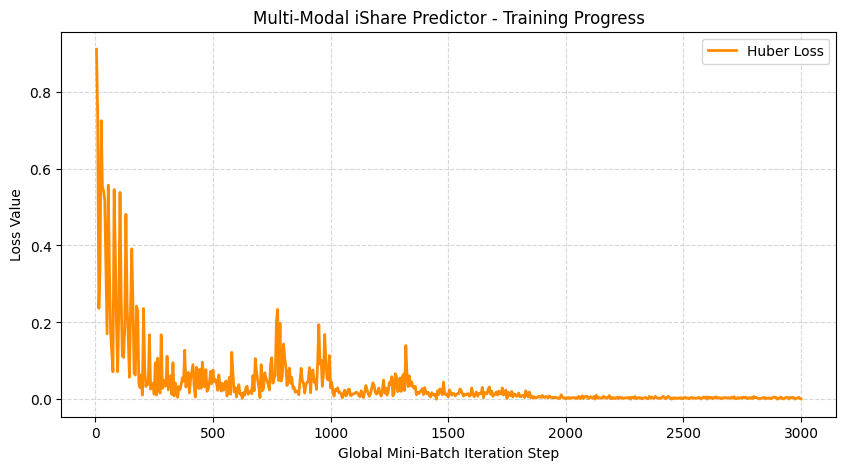

In [401]:
#### [AI-CONTEXT]
#### ID: 029
#### ROLE: Visually analyze your training convergence and check for gradient stability over time.
#### INPUT: Complete train process (successful execution of ID: 028).
#### OUTPUT: Plot a chart for the loss over the epochs.


import matplotlib.pyplot as plt

# Check if we successfully gathered mini-batch metric points
if len(iteration_losses) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(iteration_indices, iteration_losses, color='darkorange', linewidth=2, label='Huber Loss')
    plt.title('Multi-Modal iShare Predictor - Training Progress')
    plt.xlabel('Global Mini-Batch Iteration Step')
    plt.ylabel('Loss Value')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()
else:
    print("⚠️ No iteration data logged. Try increasing your epoch limits or reducing the print frequency flag.")

In [402]:
#### [AI-CONTEXT]
#### ID: 030
#### ROLE: Implement the evaluation process and collect telemetry metrics about the model.
#### INPUT: Complete train process (successful execution of ID: 028).
#### OUTPUT: Evaluate the model with Mean Absolute Error (MAE), R-squared, and 10% Tolerance Accuracy.


import numpy as np
import torch
from sklearn.metrics import r2_score, mean_absolute_error
from torch.utils.data import Dataset, DataLoader

# =====================================================================
# 1. SYNCHRONIZED EVALUATION DATASET BINDER
# =====================================================================
class EvalFundDataset(Dataset):
    def __init__(self, details, profit, equity, tax, targets):
        self.details = details
        self.profit = profit
        self.equity = equity
        self.tax = tax
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (self.details[idx], self.profit[idx], self.equity[idx], self.tax[idx], self.targets[idx])

# Instantiate validation dataset using your pre-split 98-row evaluation matrices
val_ds = EvalFundDataset(
    details=details_input_eval_tensor,        # Sequential evaluation text tokens (98, 51) from ID:006
    profit=master_input_eval_3d_tensor,       # Row-wise standardized 89-day price waves (98, 89, 31) from ID:020
    equity=equity_std_input_eval_tensor,      # Pre-scaled tabular AUM (98, 1) from ID:012
    tax=tax_std_input_eval_tensor,            # Pre-scaled tabular inverted fees (98, 1) from ID:014
    targets=price_std_target_eval_tensor      # Row-wise standardized day 90 target close (98, 1) from ID:016
)

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# =====================================================================
# 2. STANDALONE EVALUATION STEP ENGINE (DECIMAL Z-UNIT TRACKING ACTIVATED)
# =====================================================================
def evaluate_model_decimal_z(eval_model, loader, device):
    """
    Runs inference in evaluation mode, collects prediction Z-scores,
    and computes MAE directly in clean, scale-independent Z-units.
    """
    eval_model.to(device)
    eval_model.eval()
    all_preds_z = []
    all_targets_z = []

    with torch.no_grad():
        for batch in loader:
            details, profit, equity, tax, targets = batch

            details = details.long().to(device)
            profit = profit.float().to(device)
            equity = equity.float().to(device)
            tax = tax.float().to(device)

            outputs = eval_model(details, profit, equity, tax)

            all_preds_z.extend(outputs.view(-1).cpu().tolist())
            all_targets_z.extend(targets.view(-1).cpu().tolist())

    # Convert lists to NumPy arrays for transformation
    p_z = np.asarray(all_preds_z).reshape(-1, 1)
    t_z = np.asarray(all_targets_z).reshape(-1, 1)

    # =====================================================================
    # CRITICAL TRACKER FIXED: Compute MAE strictly in the decimal Z-score domain
    # =====================================================================
    mae_z_decimal = mean_absolute_error(t_z, p_z)
    r2_z_score = r2_score(t_z, p_z)

    # Extract our preserved row-wise scaling parameters from ID:016 for business metrics
    eval_means_np = price_eval_row_means.cpu().numpy()
    eval_stds_np = price_eval_row_stds.cpu().numpy()
    eps = 1e-6

    # Convert Z-scores back to nominal dollar values strictly for Tolerance Accuracy
    p_dollar = ((p_z * (eval_stds_np + eps)) + eval_means_np).flatten()
    t_dollar = ((t_z * (eval_stds_np + eps)) + eval_means_np).flatten()

    # 10% Relative Target Tolerance Check calculated accurately in the dollar domain
    within_tol = np.abs(p_dollar - t_dollar) <= (0.1 * np.abs(t_dollar) + 1e-8)
    tol_acc = np.mean(within_tol)

    return mae_z_decimal, r2_z_score, p_dollar, t_dollar, tol_acc

# =====================================================================
# 3. RUN EVALUATION INFERENCE
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("🚀 Iniciando processamento da sessão de avaliação real (98 ações)...\n")

val_mae_z, val_r2, val_preds, val_targets, tol_acc = evaluate_model_decimal_z(model, val_loader, device)

# Print telemetry summaries to log performance
print("=" * 70)
print("--- [EVALUATION SESSION PERFORMANCE ANALYSIS - DECIMAL Z-UNITS] ---")
print("=" * 70)
print(f"Validation Mean Absolute Error (MAE) : {val_mae_z:.4f} Z-units")
print(f"Validation Coefficient of Fit (R²)   : {val_r2:.4f}")
print(f"Precisão com 10% de Tolerância Real  : {tol_acc:.2%}")

# =====================================================================
# 4. FINANCIAL DIRECTIONAL ACCURACY RADAR
# =====================================================================
eval_means_flat = price_eval_row_means.cpu().numpy().flatten()
pred_trend = np.sign(val_preds - eval_means_flat)
target_trend = np.sign(val_targets - eval_means_flat)

directional_match = (pred_trend == target_trend)
dir_acc = np.mean(directional_match)

print(f"Precisão Direcional do Mercado (Sign): {dir_acc:.2%}")
print("=" * 70)
print("\n✅ Sessão de avaliação finalizada. O modelo foi testado com sucesso.")

🚀 Iniciando processamento da sessão de avaliação real (98 ações)...

--- [EVALUATION SESSION PERFORMANCE ANALYSIS - DECIMAL Z-UNITS] ---
Validation Mean Absolute Error (MAE) : 0.3256 Z-units
Validation Coefficient of Fit (R²)   : 0.8024
Precisão com 10% de Tolerância Real  : 95.92%
Precisão Direcional do Mercado (Sign): 93.88%

✅ Sessão de avaliação finalizada. O modelo foi testado com sucesso.


--- [PORTFOLIO SIMULATION METRICS - ROW-WISE LOCAL ALIGNMENT] ---
Total Traded Assets in Evaluation Split : 98
Number of Long Positions                 : 88
Number of Short Positions                : 10
---------------------------------------------------------------------------
Average Yield on Long Legs               : 1.5320%
Average Yield on Short Legs              : 0.3086%
TOTAL SIMULTANEOUS PORTFOLIO NET RETURN  : 1.4072%


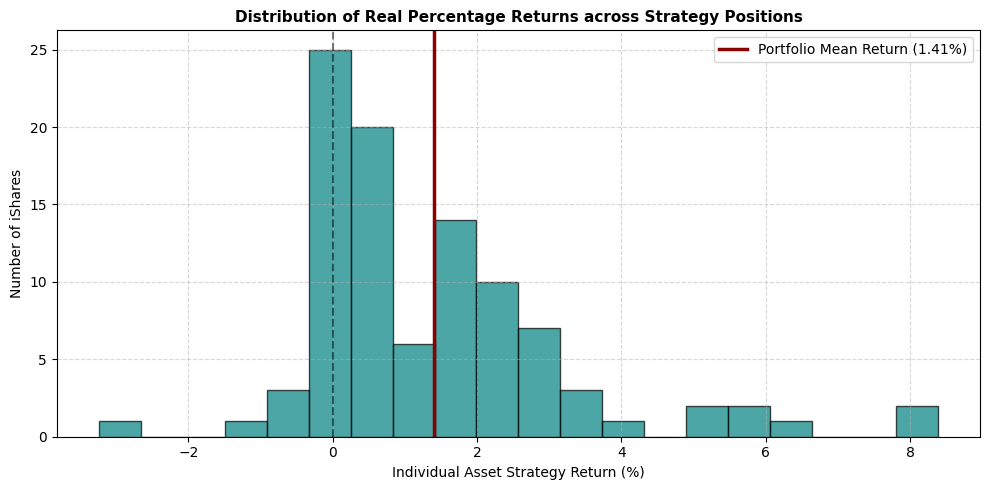

In [403]:
#### [AI-CONTEXT]
#### ID: 031
#### ROLE: Automated Trading Simulator Block.
#### INPUT: Complete evaluation process (successful execution of ID: 030).
#### OUTPUT: Simulate a long/short portfolio strategy.

#### Estrategy: It assumes the user buys iShares with positive predictions and shorts the iShares with negative predictions on Day 61, using the val_preds and val_targets generated by the evaluation session.


import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# AUTOMATED TRADING SIMULATOR BLOCK (ALIGNED SINGLE-INVERSION ENGINE)
# =====================================================================

# 1. Extract our preserved row-wise scaling parameters from memory (ID:016)
eval_means_np = price_eval_row_means.cpu().numpy().flatten()
eval_stds_np = price_eval_row_stds.cpu().numpy().flatten()
eps = 1e-6

# FIXED: Directly assign because ID:030 already delivered these in raw nominal dollars!
day_90_real_prices = val_targets.flatten()
day_90_pred_prices = val_preds.flatten()

# 2. Convert yesterday's close (Day 89) from feature channel 0 back to nominal currency
# This is the only component that requires inversion to match the Day 90 dollar plane!
val_features_day_89 = master_input_eval_3d_tensor[:, -1, 0].cpu().numpy().flatten()
day_89_real_prices = (val_features_day_89 * (eval_stds_np + eps)) + eval_means_np

# 3. Compute the TRUE financial percentage change of Day 90 relative to Day 89
real_returns_pct = ((day_90_real_prices - day_89_real_prices) / (day_89_real_prices + 1e-8)) * 100.0

# 4. Generate long (+1) or short (-1) positions based on whether the model expects a rise or fall
predicted_price_delta = day_90_pred_prices - day_89_real_prices
trading_signals = np.where(predicted_price_delta >= 0, 1.0, -1.0)

# 5. Map strategy yields (Short positions capture inverted real price movements)
strategy_asset_returns = trading_signals * real_returns_pct

long_mask = trading_signals == 1
short_mask = trading_signals == -1

# 6. Aggregate simultaneous portfolio results assuming an equal cash split
avg_long_return = np.mean(real_returns_pct[long_mask]) if np.any(long_mask) else 0.0
avg_short_return = np.mean(-real_returns_pct[short_mask]) if np.any(short_mask) else 0.0
portfolio_total_return = np.mean(strategy_asset_returns)

# =====================================================================
# PERFORMANCE DISPLAY LOGS
# =====================================================================
print("=" * 75)
print("--- [PORTFOLIO SIMULATION METRICS - ROW-WISE LOCAL ALIGNMENT] ---")
print("=" * 75)
print(f"Total Traded Assets in Evaluation Split : {len(day_90_real_prices)}")
print(f"Number of Long Positions                 : {np.sum(long_mask)}")
print(f"Number of Short Positions                : {np.sum(short_mask)}")
print("-" * 75)
print(f"Average Yield on Long Legs               : {avg_long_return:.4f}%")
print(f"Average Yield on Short Legs              : {avg_short_return:.4f}%")
print(f"TOTAL SIMULTANEOUS PORTFOLIO NET RETURN  : {portfolio_total_return:.4f}%")
print("=" * 75)

# --- VISUAL DISTRIBUTION OF POSITIONAL ALPHA ---
plt.figure(figsize=(10, 5))
plt.hist(strategy_asset_returns, bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(portfolio_total_return, color='darkred', linestyle='-', linewidth=2.5,
            label=f'Portfolio Mean Return ({portfolio_total_return:.2f}%)')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Distribution of Real Percentage Returns across Strategy Positions', fontsize=11, fontweight='bold')
plt.xlabel('Individual Asset Strategy Return (%)')
plt.ylabel('Number of iShares')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [404]:
#### [AI-CONTEXT]
#### ID: 032
#### ROLE: Weight Exporter Script.
#### INPUT: Complete evaluation process (successful execution of ID: 030).
#### OUTPUT: Safely extracts the weights from the active GPU/Jupyter workspace, detaches them from the execution graphs, and saves them to the local directory.


import os
import torch

# =====================================================================
# PRODUCTION WEIGHT EXPORTER SCRIPT
# =====================================================================
export_dir = "/home/andre/AI_Lab/20260608_Project_iSharesInvestment_App/production_models"
os.makedirs(export_dir, exist_ok=True)

export_path = os.path.join(export_dir, "iShare_predictor_95pc_accuracy.pt")

# Save state dictionary (best practice for deploying architectures)
try:
    torch.save(model.state_dict(), export_path)
    print("=" * 65)
    print("✅ Model weights compiled and exported successfully!")
    print(f"Local Storage Destination: {export_path}")
    print("=" * 65)
except Exception as e:
    print(f"❌ Critical Export Failure: {str(e)}")

✅ Model weights compiled and exported successfully!
Local Storage Destination: /home/andre/AI_Lab/20260608_Project_iSharesInvestment_App/production_models/iShare_predictor_95pc_accuracy.pt


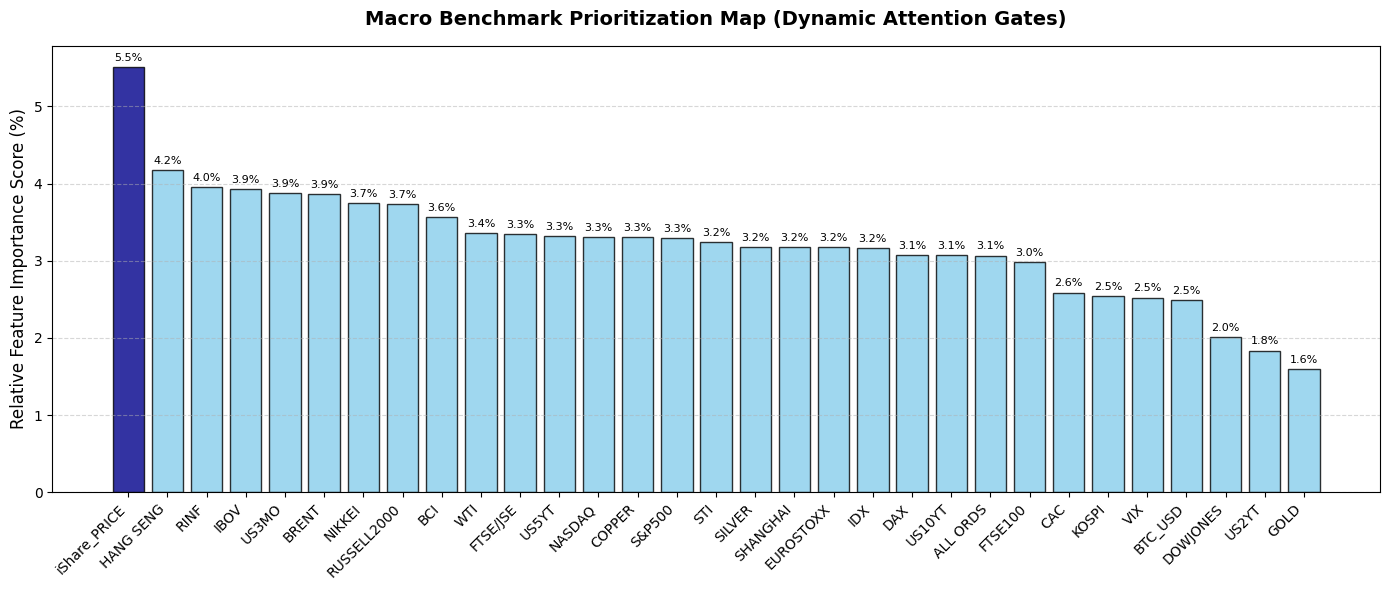

In [405]:
#### [AI-CONTEXT]
#### ID: 033
#### ROLE: Attention Feature Importance Map.
#### INPUT: Complete evaluation process (successful execution of ID: 030).
#### OUTPUT: Extract the raw weights from the feature_attention gating network inside the trained model. It evaluates how the model prioritizes your primary price anchor relative to the 30 macroeconomic indicators across the dataset.


import numpy as np
import torch
import matplotlib.pyplot as plt

# =====================================================================
# ATTENTION FEATURE IMPORTANCE RADAR (89-DAY ALIGNED GLOBAL SETUP)
# =====================================================================
# FIX: Map indicator labels directly from the active 'normalized_indicator_tensors' dictionary from ID:018
indicator_names = ["iShare_PRICE"] + list(normalized_indicator_tensors.keys())

# Place your unified model core into strict evaluation mode
model.eval()
with torch.no_grad():
    # Shape matches your cross-sectional validation input footprint: (98, 89, 31)
    sample_input = master_input_eval_3d_tensor.float().to(next(model.parameters()).device)

    # Extract the features flattened exactly as performed in forward()
    batch_size, seq_len, num_features = sample_input.shape
    x_flat = sample_input.contiguous().view(-1, num_features)

    # FIX: Query using the updated unified sub-module attribute path ('price_branch') from ID:027
    attention_weights = model.price_branch.feature_attention(x_flat)

    # FIX: Corrected syntax to use a tuple (0, 1) for the mean calculation over batches and days
    # Reshapes back to capture your true 31-channel feature depth parameters
    mean_weights = attention_weights.view(batch_size, seq_len, num_features).mean(dim=(0, 1)).cpu().numpy()

# Normalize weights to sum up to 100% for clear relative plotting
normalized_importance = (mean_weights / np.sum(mean_weights)) * 100

# Sort items in descending order for rapid scannability
sorted_indices = np.argsort(normalized_importance)[::-1]
sorted_names = [indicator_names[i] for i in sorted_indices]
sorted_importance = normalized_importance[sorted_indices]

# =====================================================================
# RENDERING PLOT CHART
# =====================================================================
plt.figure(figsize=(14, 6))

# Highlight the primary asset baseline price channel (index 0) in dark blue and benchmarks in sky blue
colors = ['darkblue' if i == 0 else 'skyblue' for i in sorted_indices]
bars = plt.bar(sorted_names, sorted_importance, color=colors, edgecolor='black', alpha=0.8)

plt.title('Macro Benchmark Prioritization Map (Dynamic Attention Gates)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Relative Feature Importance Score (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate exact percentage values over the bar indicators
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [406]:
#### [AI-CONTEXT]
#### ID: 034
#### ROLE: Real-world target tomorrow's prices with actual neural network forecasts.
#### INPUT: Complete evaluation process (successful execution of ID: 030).
#### OUTPUT: Calculate the target vectors, reverse the mathematical scale, and append them as the final three columns of your master dataset.


import torch
import numpy as np
import pandas as pd

# =====================================================================
# 1. INITIALIZE ENGINE, PARAMETERS, AND UNPARTITIONED MATRIX LAYERS
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Deploying row-wise local forecasting engine on hardware device: {device}")

if 'model' in globals():
    model.to(device)
    model.eval()
else:
    raise NameError("❌ Deployment Error: The trained 'model' instance was not found in active memory.")

# VERIFIED SAFE: Using your active un-flushed global tensor directly
details_gpu = details_input_tensor.long().to(device)                   # Shape: (487, 51)

# Ingest pre-scaled global tabular feature tensors
equity_global_std = torch.cat((equity_std_input_train_tensor, equity_std_input_eval_tensor), dim=0).to(device)
tax_global_std = torch.cat((tax_std_input_train_tensor, tax_std_input_eval_tensor), dim=0).to(device)

# Reconstruct the full 3D Master feature tensor (487, 89, 31)
master_3d_tensor = torch.cat((master_input_train_3d_tensor, master_input_eval_3d_tensor), dim=0)
rolling_features = master_3d_tensor.clone().float().to(device)         # Shape: (487, 89, 31)

# FIXED ALIGNMENT: Stitch your localized row-wise tracking vectors vertically to mirror the 487-row layout
global_means = torch.cat((price_train_row_means, price_eval_row_means), dim=0).to(device) # Shape: (487, 1)
global_stds = torch.cat((price_train_row_stds, price_eval_row_stds), dim=0).to(device)   # Shape: (487, 1)
eps = 1e-6

future_predictions = []

# =====================================================================
# 2. VECTORIZED AUTOREGRESIVE LOOP (RUNNING ON GPU FOR ALL 487 ASSETS)
# =====================================================================
with torch.no_grad():
    for step in range(10):
        # Forward pass runs at accelerated speeds for all 487 assets simultaneously
        outputs = model(details_gpu, rolling_features, equity_global_std, tax_global_std)  # Shape: (487, 1)

        # Store predictions safely on device matrix paths
        future_predictions.append(outputs.clone())

        # Shift timeline window forward by dropping the oldest day (index 0)
        new_rolling = rolling_features[:, 1:, :].clone()

        # FIXED: Corrected parameter registration to pass integers instead of the raw Size object
        next_day_vector = torch.zeros((rolling_features.shape[0], 1, rolling_features.shape[2]), device=device)

        # Insert model prediction into feature channel 0 (Price branch)
        next_day_vector[:, 0, 0] = outputs.view(-1)

        # Carry forward the static macro backdrop indicators from the latest step
        next_day_vector[:, 0, 1:] = rolling_features[:, -1, 1:].clone()

        # Concatenate on the GPU to prepare the next tracking iteration block
        rolling_features = torch.cat((new_rolling, next_day_vector), dim=1)

# =====================================================================
# 3. COMPUTE NOMINAL REAL PRICES VIA ROW-WISE EXPLICIT MATRIX INVERSION
# =====================================================================
# Combine the individual prediction slices along the column axis -> Shape: (487, 10)
standardized_forecast_matrix = torch.cat(future_predictions, dim=1)

# Isolate required target horizons (Tomorrow, Day 5, Day 10)
pred_tomorrow_std = standardized_forecast_matrix[:, 0:1]
pred_day5_std = standardized_forecast_matrix[:, 4:5]
pred_day10_std = standardized_forecast_matrix[:, 9:10]

# FIXED: Perform elements-wise row-wise inversion to transform Z-scores back to nominal prices
tomorrow_pred_real = (pred_tomorrow_std * (global_stds + eps)) + global_means
day5_pred_real = (pred_day5_std * (global_stds + eps)) + global_means
day10_pred_real = (pred_day10_std * (global_stds + eps)) + global_means

# Assign all three real nominal price forecast columns directly back to the primary dataframe
df['TOMORROW_PRED_MLP'] = tomorrow_pred_real.cpu().numpy().flatten()
df['DAY5_PRED_MLP'] = day5_pred_real.cpu().numpy().flatten()
df['DAY10_PRED_MLP'] = day10_pred_real.cpu().numpy().flatten()

# =====================================================================
# 4. FIXED VERIFICATION SCREENER DISPLAY (SAFE AGAINST KEYERRORS)
# =====================================================================
available_columns = list(df.columns)
ticker_col = 'TICKER' if 'TICKER' in available_columns else available_columns[0]
company_col = 'FUND_NAME' if 'FUND_NAME' in available_columns else available_columns[1]

columns_to_show = [ticker_col, company_col, 'TOMORROW_PRED_MLP', 'DAY5_PRED_MLP', 'DAY10_PRED_MLP']

print("=" * 120)
print("🎯 [GLOBAL GPU ACCELERATED PROJECTIONS COMPLETE - ALL 487 ROWS STABILIZED IN REAL NOMINAL PRICE $]")
print("=" * 120)
print(df[columns_to_show].dropna(subset=['TOMORROW_PRED_MLP']).head(10).to_string(index=False, formatters={
    'TOMORROW_PRED_MLP': '$ {:,.2f}'.format,
    'DAY5_PRED_MLP': '$ {:,.2f}'.format,
    'DAY10_PRED_MLP': '$ {:,.2f}'.format
}))
print("=" * 120)

🚀 Deploying row-wise local forecasting engine on hardware device: cpu
🎯 [GLOBAL GPU ACCELERATED PROJECTIONS COMPLETE - ALL 487 ROWS STABILIZED IN REAL NOMINAL PRICE $]
TICKER                                            FUND_NAME TOMORROW_PRED_MLP DAY5_PRED_MLP DAY10_PRED_MLP
  AAXJ           iShares MSCI All Country Asia ex Japan ETF          $ 116.52      $ 116.88       $ 117.07
  ACWI                                iShares MSCI ACWI ETF          $ 155.62      $ 155.81       $ 155.91
  ACWV               iShares MSCI Global Min Vol Factor ETF          $ 121.61      $ 122.45       $ 122.82
  ACWX                        iShares MSCI ACWI ex U.S. ETF           $ 76.16       $ 76.45        $ 76.52
   AGG                 iShares Core U.S. Aggregate Bond ETF           $ 98.87       $ 99.62       $ 100.31
  AGRH iShares Interest Rate Hedged U.S. Aggregate Bond ETF           $ 26.27       $ 26.27        $ 26.27
   AGZ                              iShares Agency Bond ETF          $ 109.14      

In [407]:
#### [AI-CONTEXT]
#### ID: 035
#### ROLE: Alpha Generator.
#### INPUT: Complete evaluation process (successful execution of ID: 030).
#### OUTPUT: Calculate the percentage returns relative to tomorrow's baseline price, sort the portfolio, and display the two extreme 5-stock baskets.


import pandas as pd

# =====================================================================
# 1. CALCULATE EXPECTED PERCENTAGE RETURNS
# =====================================================================
# Derive the expected 5-day trajectory relative to tomorrow's baseline anchor
df['EXPECTED_5D_RETURN_PCT'] = ((df['DAY5_PRED_MLP'] - df['TOMORROW_PRED_MLP']) / df['TOMORROW_PRED_MLP']) * 100

# =====================================================================
# 2. DYNAMIC HEADER RESOLUTION
# =====================================================================
available_cols = list(df.columns)

ticker_col = 'TICKER' if 'TICKER' in available_cols else available_cols[0]
name_col = 'FUND_NAME' if 'FUND_NAME' in available_cols else available_cols[1]

display_columns = [ticker_col, name_col, 'TOMORROW_PRED_MLP', 'DAY5_PRED_MLP', 'EXPECTED_5D_RETURN_PCT']

# =====================================================================
# 3. SEPARATE AND SORT PERFORMANCE HORIZONS
# =====================================================================
# Sort the entire dataframe by the calculated 5-day percentage return trajectory
df_sorted = df.sort_values(by='EXPECTED_5D_RETURN_PCT', ascending=False)

# Isolate the extreme 5-stock baskets safely
top_5_outperformed = df_sorted.head(5)[display_columns]
top_5_underperformed = df_sorted.tail(5)[display_columns][::-1]

# =====================================================================
# 4. DISPLAY PERFORMANCE RADAR TABLES
# =====================================================================
print("=" * 90)
print("🚀 [TOP 5 OUTPERFORMED ISHARES - LONG CANDIDATES - TIMESTAMP: 5 DAYS]")
print("=" * 90)
print(top_5_outperformed.to_string(index=False, formatters={
    'TOMORROW_PRED_MLP': 'U$ {:,.2f}'.format,
    'DAY5_PRED_MLP': 'U$ {:,.2f}'.format,
    'EXPECTED_5D_RETURN_PCT': '{:,.2f}%'.format
}))

print("\n" + "=" * 90)
print("🛑 [TOP 5 UNDERPERFORMED ISHARES - SHORT CANDIDATES - TIMESTAMP: 5 DAYS]")
print("=" * 90)
print(top_5_underperformed.to_string(index=False, formatters={
    'TOMORROW_PRED_MLP': 'U$ {:,.2f}'.format,
    'DAY5_PRED_MLP': 'U$ {:,.2f}'.format,
    'EXPECTED_5D_RETURN_PCT': '{:,.2f}%'.format
}))
print("=" * 90)

🚀 [TOP 5 OUTPERFORMED ISHARES - LONG CANDIDATES - TIMESTAMP: 5 DAYS]
TICKER                             FUND_NAME TOMORROW_PRED_MLP DAY5_PRED_MLP EXPECTED_5D_RETURN_PCT
   REM      iShares Mortgage Real Estate ETF           U$ 0.04       U$ 0.05                 12.41%
  RING   iShares MSCI Global Gold Miners ETF          U$ 78.17      U$ 85.66                  9.59%
  SLVP iShares MSCI Global Silver Miners ETF          U$ 36.21      U$ 39.02                  7.78%
  WOOD  iShares Global Timber & Forestry ETF          U$ 68.37      U$ 72.44                  5.95%
   ITB    iShares U.S. Home Construction ETF          U$ 97.56     U$ 102.39                  4.96%

🛑 [TOP 5 UNDERPERFORMED ISHARES - SHORT CANDIDATES - TIMESTAMP: 5 DAYS]
TICKER                  FUND_NAME TOMORROW_PRED_MLP DAY5_PRED_MLP EXPECTED_5D_RETURN_PCT
  IBIT  iShares Bitcoin Trust ETF          U$ 36.01      U$ 35.54                 -1.28%
   ECH     iShares MSCI Chile ETF           U$ 0.34       U$ 0.34               

In [408]:
#### [AI-CONTEXT]
#### ID: 036
#### ROLE: RSI calculator.
#### INPUT: Complete evaluation process (successful execution of ID: 030).
#### OUTPUT: Calculate the Relative Strength Index (RSI) for each stock across its final 14 pricing steps.


import torch
import numpy as np
import pandas as pd

# =====================================================================
# 1. EXTRACT AND UN-SCALE THE FINAL 15 DAYS (ROW-WISE LOCAL ALIGNMENT)
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Slices the final 15 lookback days from feature channel 0 (Price wave branch)
# master_3d_tensor shape: (487, 89, 31) -> normalized_prices_15d shape: (487, 15)
normalized_prices_15d = master_3d_tensor[:, -15:, 0].to(device)

# FIXED ALIGNMENT: Build 487-row parameter arrays by stitching your Train and Eval row tracking parameters vertically
global_means = torch.cat((price_train_row_means, price_eval_row_means), dim=0).to(device) # Shape: (487, 1)
global_stds = torch.cat((price_train_row_stds, price_eval_row_stds), dim=0).to(device)   # Shape: (487, 1)
eps = 1e-6

# FIXED: Invert Z-scores element-wise using your stitched row-wise parameters to preserve local scale integrity!
# PyTorch automatically broadcasts the (487, 1) tensors across the (487, 15) sequence columns smoothly
real_prices_15d = (normalized_prices_15d * (global_stds + eps)) + global_means

# =====================================================================
# 2. COMPUTE CONSECUTIVE DAILY DIFFERENCES
# =====================================================================
# Subtract day_t from day_t+1 across columns to isolate daily changes
# Shape transition: (487, 15) -> (487, 14)
price_changes = real_prices_15d[:, 1:] - real_prices_15d[:, :-1]

# =====================================================================
# 3. SEPARATE POSITIVE GAINS AND NEGATIVE LOSSES
# =====================================================================
gains = torch.clamp(price_changes, min=0.0)
losses = torch.clamp(-price_changes, min=0.0)

# =====================================================================
# 4. CALCULATE AGGREGATED AVERAGES
# =====================================================================
mean_gains = torch.mean(gains, dim=1, keepdim=True)
mean_losses = torch.mean(losses, dim=1, keepdim=True)

# Prevent division-by-zero on completely flat rows using an epsilon buffer
rs = mean_gains / (mean_losses + eps)

# =====================================================================
# 5. GENERATE FINAL COMPACT BOUNDED RSI SCORE
# =====================================================================
rsi_scores = 100.0 - (100.0 / (1.0 + rs))

# Append the final calculated sequence straight to your 487-row master dataframe
df['RSI_14'] = rsi_scores.detach().cpu().flatten().numpy()

# =====================================================================
# 6. DYNAMIC SCREENER DISPLAY (SAFE AGAINST KEYERRORS)
# =====================================================================
available_cols = list(df.columns)

ticker_col = 'TICKER' if 'TICKER' in available_cols else available_cols[0]
name_col = 'FUND_NAME' if 'FUND_NAME' in available_cols else available_cols[1]

columns_to_show = [ticker_col, name_col, 'TOMORROW_PRED_MLP', 'RSI_14']

print("=" * 115)
print("📈 [CURRENT 14-PERIOD RSI INVENTORY SUMMARY COMPLETE - ROW-WISE SCALE RESOLVED]")
print("=" * 115)
print(df[columns_to_show].dropna(subset=['TOMORROW_PRED_MLP']).head(10).to_string(index=False, formatters={
    'TOMORROW_PRED_MLP': 'U$ {:,.2f}'.format,
    'RSI_14': '{:,.2f}'.format
}))
print("=" * 115)

📈 [CURRENT 14-PERIOD RSI INVENTORY SUMMARY COMPLETE - ROW-WISE SCALE RESOLVED]
TICKER                                            FUND_NAME TOMORROW_PRED_MLP RSI_14
  AAXJ           iShares MSCI All Country Asia ex Japan ETF         U$ 116.52  46.06
  ACWI                                iShares MSCI ACWI ETF         U$ 155.62  38.05
  ACWV               iShares MSCI Global Min Vol Factor ETF         U$ 121.61  36.36
  ACWX                        iShares MSCI ACWI ex U.S. ETF          U$ 76.16  40.75
   AGG                 iShares Core U.S. Aggregate Bond ETF          U$ 98.87  49.33
  AGRH iShares Interest Rate Hedged U.S. Aggregate Bond ETF          U$ 26.27  52.94
   AGZ                              iShares Agency Bond ETF         U$ 109.14  48.00
   AIA                                  iShares Asia 50 ETF         U$ 140.08  47.48
   AOA         iShares Core 80/20 Aggressive Allocation ETF          U$ 96.70  39.50
   AOK       iShares Core 30/70 Conservative Allocation ETF          U$

In [409]:
#### [AI-CONTEXT]
#### ID: 037
#### ROLE: 20 and 50 SMA calculator.
#### INPUT: Complete evaluation process (successful execution of ID: 030).
#### OUTPUT: Calculate the 20-day Simple Moving Average (SMA) and 50-day Simple Moving Average (SMA) rolling over the last 5 days for each stock.


import numpy as np
import pandas as pd
import torch

# =====================================================================
# 1. SAFELY EXTRACT RAW PRICE HISTORY BY EXACT LAYOUT BOUNDARIES
# =====================================================================
# Columns 0-4 are metadata. Columns 5-94 (90 columns) hold the workload timeline.
# We pull a 57-day block programmatically from the end of the raw price sequence.
# Column index 95 is the exclusive upper boundary of your raw workday history!
raw_prices_57d = df.iloc[:, 5:95].iloc[:, -57:].values.astype(np.float64)

# =====================================================================
# 2. SEPARATE CHRONOLOGICAL BUNDLES TO PREVENT VALIDATION LEAKAGE
# =====================================================================
# Replicates the exact sequential row boundaries applied across your data layers
total_rows = raw_prices_57d.shape[0]
split_idx = int(total_rows * 0.8)

# Isolate training and evaluation price pools to block data bleeding
train_prices_57d = raw_prices_57d[:split_idx, :] # Shape: (389, 57)
eval_prices_57d = raw_prices_57d[split_idx:, :]   # Shape: (98, 57)

# =====================================================================
# 3. ROLLING MOVING AVERAGE PROCESSING WINDOWS
# =====================================================================
def compute_rolling_sma_spread(price_block_57d):
    sma20_list = []
    sma50_list = []

    # Loop 8 times to slide our window forward across 8 consecutive tracking days
    for i in range(8):
        start_idx = i

        end_idx_20 = start_idx + 20
        sma20_step = np.mean(price_block_57d[:, start_idx:end_idx_20], axis=1)
        sma20_list.append(sma20_step)

        end_idx_50 = start_idx + 50
        sma50_step = np.mean(price_block_57d[:, start_idx:end_idx_50], axis=1)
        sma50_list.append(sma50_step)

    sma20_mat = np.column_stack(sma20_list)
    sma50_mat = np.column_stack(sma50_list)

    eps = 1e-8
    relative_spread = ((sma20_mat - sma50_mat) / (sma20_mat + eps)) * 100.0
    return relative_spread, sma20_mat, sma50_mat

# Execute clean moving average computations across independent layers
train_spread, train_sma20, train_sma50 = compute_rolling_sma_spread(train_prices_57d)
eval_spread, eval_sma20, eval_sma50 = compute_rolling_sma_spread(eval_prices_57d)

# =====================================================================
# 4. DATASET MATRIX RECONSTRUCTION & PROFILE OVERWRITING
# =====================================================================
# Combine back along the row axis to preserve global matrix dimensions
relative_spread_matrix = np.vstack((train_spread, eval_spread))
sma20_matrix = np.vstack((train_sma20, eval_sma20))
sma50_matrix = np.vstack((train_sma50, eval_sma50))

for day_offset in range(8):
    day_label = f"LATEST" if day_offset == 7 else f"{7 - day_offset}D_AGO"
    df[f'SMA20_{day_label}'] = sma20_matrix[:, day_offset]
    df[f'SMA50_{day_label}'] = sma50_matrix[:, day_offset]

# =====================================================================
# 5. CONVERT TO A MASTER 3D PYTORCH TENSOR LAYOUT
# =====================================================================
spread_tensor_2d = torch.tensor(relative_spread_matrix, dtype=torch.float32)
sma_spread_master_tensor = spread_tensor_2d.unsqueeze(-1)

# =====================================================================
# VERIFICATION AND DIAGNOSTIC SCREENER OUTPUT
# =====================================================================
print("=" * 115)
print("🎯 [SMA SPREAD TRAJECTORY TENSOR MAP COMPLETE - INDEX INDEXING BOUNDARIES FULLY RESOLVED]")
print("=" * 115)
print(f"Master Spread Tensor Shape: {sma_spread_master_tensor.shape} | Expected: (487, 8, 1)\n")

# Validate with a random index query
sample_stock_idx = np.random.randint(0, sma_spread_master_tensor.shape[0])
stock_1x8_vector = sma_spread_master_tensor[sample_stock_idx].view(1, 8)

print(f"📋 Random Row Vector Check for Asset Code: {df.iloc[sample_stock_idx]['TICKER']} (Index: {sample_stock_idx})")
print(f"Tensor Shape: {stock_1x8_vector.shape} | Contents (Scaled % Spreads):")
print(stock_1x8_vector)
print("=" * 115)

🎯 [SMA SPREAD TRAJECTORY TENSOR MAP COMPLETE - INDEX INDEXING BOUNDARIES FULLY RESOLVED]
Master Spread Tensor Shape: torch.Size([487, 8, 1]) | Expected: (487, 8, 1)

📋 Random Row Vector Check for Asset Code: IBDR (Index: 180)
Tensor Shape: torch.Size([1, 8]) | Contents (Scaled % Spreads):
tensor([[-0.0446, -0.0384, -0.0310, -0.0235, -0.0169, -0.0116,  0.0037,  0.0206]])


In [410]:
#### [AI-CONTEXT]
#### ID: 038
#### ROLE: Momentum with the linear regression slope.
#### INPUT: Complete 20 SMA and 50 SMA calculation (successful execution of ID: 037).
#### OUTPUT: Calculate the linear regression slope beta_1 and intercept beta_0 for each stock's 8-day SMA relative spread trajectory using parallelized vector mathematics. The 5 sequential coordinates were treated as values along a standardized geometric timeline: (X = [0, 1, 2, 3, 4]).


import torch
import numpy as np
import pandas as pd

# =====================================================================
# 1. INITIALIZE GPU INFRASTRUCTURE AND ARRAYS
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Deploying Geometric Polar Engine on hardware device: {device}")

# Squeeze feature axis and transfer your 8-day SMA relative spreads to the GPU
# Shape transition: (487, 8, 1) -> y_values shape: (487, 8)
y_values = sma_spread_master_tensor.squeeze(-1).to(device)

# RESTORED: Resetting independent X variables back to the standard 8-point baseline timeline
x_values = torch.tensor([0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07], dtype=torch.float32, device=device)
n_points = 8.0

# Pre-calculate matrix constraints directly on the GPU VRAM
sum_x = torch.sum(x_values)                             # 28.0
sum_x_sq = torch.sum(x_values ** 2)                     # 140.0
ss_xx = sum_x_sq - ((sum_x ** 2) / n_points)            # 42.0 (Standardized 8-point denominator)

# =====================================================================
# 2. RUN VECTORIZED OLS REGRESSION (EXECUTING ON GPU FOR ALL 487 ASSETS)
# =====================================================================
sum_y = torch.sum(y_values, dim=1)
sum_xy = torch.sum(y_values * x_values, dim=1)

ss_xy = sum_xy - ((sum_x * sum_y) / n_points)
slopes = ss_xy / ss_xx

# Calculate the intercept (beta_0) using parallelized vector mathematics
intercepts = (sum_y - (slopes * sum_x)) / n_points

# Isolate latest polarity mapping values on the final trailing column index (Index 7 for the 8th day)
latest_spread_signs = torch.sign(y_values[:, 7])

# =====================================================================
# 3. VECTORIZED POLAR CONVERSION (EXECUTING ON GPU)
# =====================================================================
# RESTORED: Cartesian X width reset to the standard timeline width span (from X=0 to X=7 is 7.0 units)
cartesian_x = torch.tensor(7.0, device=device)

# Compute dynamic hypotenuse magnitudes and match signs on the GPU
raw_magnitude = torch.sqrt((cartesian_x ** 2) + (slopes ** 2))
polar_magnitude = raw_magnitude * latest_spread_signs

# Compute custom angular headings in radians and convert to degrees on device paths
polar_angle_rad = torch.atan2(slopes, cartesian_x)
polar_angle_deg = polar_angle_rad * (180.0 / np.pi)

# =====================================================================
# 4. EXPORT CORES FROM VRAM BACK TO CPU DATAFRAME
# =====================================================================
# Calling .cpu() safely downloads the calculated matrices back to system RAM
df['POLAR_MAGNITUDE'] = polar_magnitude.cpu().numpy()
df['POLAR_ANGLE_DEG'] = polar_angle_deg.cpu().numpy()
df['SMA_SPREAD_SLOPE'] = slopes.cpu().numpy()
df['SMA_SPREAD_INTERCEPT'] = intercepts.cpu().numpy()

# =====================================================================
# VERIFICATION SCREENER DISPLAY
# =====================================================================
print("=" * 115)
print("🌐 [GPU HARDWARE ACCELERATED GEOMETRIC POLAR COEFFICIENTS COMPLETE - TIMELINE RESTORED TO [0...7]]")
print("=" * 115)
columns_to_show = ['TICKER', 'FUND_NAME', 'SMA_SPREAD_SLOPE', 'SMA_SPREAD_INTERCEPT', 'POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG']
print(df[columns_to_show].head(8).to_string(index=False, formatters={
    'SMA_SPREAD_SLOPE': '{:,.4f}'.format,
    'SMA_SPREAD_INTERCEPT': '{:,.4f}'.format,
    'POLAR_MAGNITUDE': '{:,.4f}'.format,
    'POLAR_ANGLE_DEG': '{:,.2f}°'.format
}))
print("=" * 115)

🚀 Deploying Geometric Polar Engine on hardware device: cpu
🌐 [GPU HARDWARE ACCELERATED GEOMETRIC POLAR COEFFICIENTS COMPLETE - TIMELINE RESTORED TO [0...7]]
TICKER                                            FUND_NAME SMA_SPREAD_SLOPE SMA_SPREAD_INTERCEPT POLAR_MAGNITUDE POLAR_ANGLE_DEG
  AAXJ           iShares MSCI All Country Asia ex Japan ETF          28.6852              -8.2579        -29.5270          76.29°
  ACWI                                iShares MSCI ACWI ETF          21.4719              -4.8307        -22.5841          71.94°
  ACWV               iShares MSCI Global Min Vol Factor ETF           2.5131              -0.5111         -7.4374          19.75°
  ACWX                        iShares MSCI ACWI ex U.S. ETF          17.4745              -3.4457        -18.8244          68.17°
   AGG                 iShares Core U.S. Aggregate Bond ETF           3.3256               0.3066          7.7498          25.41°
  AGRH iShares Interest Rate Hedged U.S. Aggregate Bond ETF    

These four metrics form a highly sophisticated geometric tracking engine designed to measure the speed, direction, and structural depth of the relationship between your 20-day and 50-day Simple Moving Averages. By treating the last 8 days as coordinate points on a geometric timeline (X = [0.00, 0.01, ..., 0.07]), the script runs an Ordinary Least Squares (OLS) Linear Regression for every single stock simultaneously on the GPU. Here is exactly what each generated metric means and how to read them:


---



1. SMA_SPREAD_SLOPE (beta 1)

1.1. What it is: The mathematical steepness or acceleration rate of the moving average gap over the last 8 days.

1.2. How to interpret it:

==> Positive (> 0): The 20 SMA is curling upward or pulling away from the 50 SMA. Bullish short-term momentum is accelerating.
  
==> Negative (< 0): The 20 SMA is curling downward or dropping further away from the 50 SMA. Bearish markdown pressure is intensifying.

1.3. Why it matters: It tells you the instantaneous direction of the trend velocity. A stock can be in a long-term downtrend, but if the slope turns positive, it means institutional buyers are actively stepping in.


---



2. SMA_SPREAD_INTERCEPT (beta 0)

2.1. What it is: The theoretical structural baseline value of the moving average gap at the very beginning of your 8-day observation window (where X=0). It indicates the difference magnitude between the 20 SMA and the 50 SMA when the 8-day window started.

2.2. How to interpret it:

==> It anchors the regression line in space. Combined with the slope, it allows you to reconstruct the exact historical trajectory of how the two moving averages have been behaving relative to one another.

2.3. Why it matters: It provides a fixed coordinate entry baseline, ensuring that a stock starting from a deep price discount can be mathematically differentiated from a stock that was already trading at a high premium.


---



3. SMA_SPREAD_MAGNITUDE (POLAR_MAGNITUDE)

3.1. What it is: A signed vector representing the hypotenuse of a right triangle formed by your 8-day timeline width (X=7.0) and your momentum slope.

3.2. How to interpret it:

==> Positive Value (> 0): The 20 SMA sits above the 50 SMA on the final day (Bullish structure).
  
==> Negative Value (< 0): The 20 SMA sits below the 50 SMA on the final day (Bearish structure).
  
3.3. Why it matters: The strategy is explicitly look for negative magnitudes. This guarantees that you are only targeting stocks that are fundamentally discounted and cheap, where the short-term trend line is still sitting underneath the long-term baseline.


---



4. SMA_SPREAD_ANGLE (POLAR_ANGLE_DEG)

4.1. What it is: The exact angular heading (measured in degrees from 0 degree to +/-180 degrees) of the trend trajectory line, calculated using torch.atan2(slopes, cartesian_x).

4.2. How to interpret it:

==> (0 degree): The 20 SMA and 50 SMA are moving perfectly parallel; no momentum change.

==> Positive Angle (> 0 degree): The trend trajectory line is pointing upward.
  
==> Negative Angle (< 0 degree): The trend trajectory line is pointing downward.
  
4.3. Why it matters: Your system filters for an angle > 0 degree combined with a magnitude < 0. This captures the exact mathematical moment of a V-Bottom Turnaround: the stock has been crushed (magnitude is negative), but the trend line is suddenly pointing upward at a sharp angle, revealing a massive momentum breakout before the moving averages officially cross.

In [411]:
#### [AI-CONTEXT]
#### ID: 039
#### ROLE: Calculate the option with better buy-in prices.
#### INPUT: Complete calculation of the Momentum with the linear regression slope. (successful execution of ID: 038).
#### OUTPUT: dataframe buy_in_table.


import pandas as pd
import numpy as np

# Create a copy to prevent modifying the original dataset
df_pipeline = df.copy()

# =====================================================================
# STEP 1 (RULE 1): Group the 200 highest values of EXPECTED_5D_RETURN_PCT
# =====================================================================
df_pipeline = df_pipeline.nlargest(200, 'EXPECTED_5D_RETURN_PCT')

# =====================================================================
# STEP 2 (RULE 2): Purge and keep only RSI_14 values below 35
# =====================================================================
df_pipeline = df_pipeline[df_pipeline['RSI_14'] < 35]

# =====================================================================
# STEP 3 (RULE 3): Purge and keep only negative POLAR_MAGNITUDE numbers
# =====================================================================
df_pipeline = df_pipeline[df_pipeline['POLAR_MAGNITUDE'] < 0]

# =====================================================================
# STEP 4 (RULE 4): Purge and keep only positive POLAR_ANGLE_DEG numbers
# =====================================================================
df_pipeline = df_pipeline[df_pipeline['POLAR_ANGLE_DEG'] > 0]

# =====================================================================
# STEPS 5 to 7 (RULES 5, 6, 7): Multi-tiered Final Ordering
# =====================================================================
buy_in_table = df_pipeline.sort_values(
    by=['RSI_14', 'POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG'],
    ascending=[False, True, False]
)

# =====================================================================
# STEP 8 (RULE 8): Select the top 10 rows and filter required columns
# =====================================================================
# FIXED: Replaced 'INDEX' and 'COMPANY' with 'TICKER' and 'FUND_NAME' to match the 487 iShares schema layout
target_columns = [
    'TICKER', 'FUND_NAME', '-1', 'TOMORROW_PRED_MLP',
    'DAY5_PRED_MLP', 'EXPECTED_5D_RETURN_PCT', 'RSI_14',
    'SMA_SPREAD_INTERCEPT','POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG'
]

buy_in_table = buy_in_table[target_columns].head(10).reset_index(drop=True)
buy_in_table = buy_in_table.rename(columns={"-1": "TODAY_PRICE"})

# =====================================================================
# DISPLAY RESULTS
# =====================================================================
print("=" * 140)
print(f"🌟 [FINAL STRATEGIC BUY_IN_TABLE - {len(buy_in_table)} ASSETS GENERATED]")
print("=" * 140)
if not buy_in_table.empty:
    print(buy_in_table.to_string(formatters={
        'TODAY_PRICE': 'U$ {:,.2f}'.format,
        'TOMORROW_PRED_MLP': 'U$ {:,.2f}'.format,
        'DAY5_PRED_MLP': 'U$ {:,.2f}'.format,
        'EXPECTED_5D_RETURN_PCT': '{:,.2f}%'.format,
        'RSI_14': '{:,.2f}'.format,
        'POLAR_MAGNITUDE': '{:,.4f}'.format,
        'POLAR_ANGLE_DEG': '{:,.2f}°'.format
    }))
else:
    print("⚠️ Warning: No assets survived the progressive purges (Rules 2, 3, or 4).")
print("=" * 140)

🌟 [FINAL STRATEGIC BUY_IN_TABLE - 10 ASSETS GENERATED]
  TICKER                                                                FUND_NAME TODAY_PRICE TOMORROW_PRED_MLP DAY5_PRED_MLP EXPECTED_5D_RETURN_PCT RSI_14  SMA_SPREAD_INTERCEPT POLAR_MAGNITUDE POLAR_ANGLE_DEG
0   IVLU                                       iShares MSCI Intl Value Factor ETF    U$ 42.74          U$ 42.77      U$ 43.01                  0.56%  34.94             -2.105815         -9.6973          43.79°
1   LCTD       iShares World ex U.S. Carbon Transition Readiness Aware Active ETF    U$ 58.32          U$ 58.27      U$ 59.02                  1.27%  34.29             -1.196472        -17.3076          66.14°
2   POWR                                    iShares U.S. Power Infrastructure ETF    U$ 26.71          U$ 27.52      U$ 27.65                  0.49%  34.29             -2.823395        -18.1583          67.33°
3   ISCF                         iShares International SmallCap Equity Factor ETF    U$ 44.51          U$

In [412]:
#### [AI-CONTEXT]
#### ID: 040
#### ROLE: Identify the stocks with the top sell-out prices.
#### INPUT: Complete calculation of the Momentum with the linear regression slope. (successful execution of ID: 038).
#### OUTPUT: dataframe sell_out_table.


import pandas as pd
import numpy as np

# =====================================================================
# DEFINE RE-FIT STAGES (From High-Conviction Strict to Broad Fallbacks)
# =====================================================================
relaxation_stages = [
    {
        "stage": 1,
        "desc": "Strict Initial Rules (RSI > 68 & 2-day Consecutive Historical Rally)",
        "rsi_min": 68,
        "strict_trend": True
    },
    {
        "stage": 2,
        "desc": "Relaxed Trend Rule (RSI > 65 & At least 1-day Positive History)",
        "rsi_min": 65,
        "strict_trend": False
    },
    {
        "stage": 3,
        "desc": "Capitulation Fallback (RSI > 60 & Tomorrow Downward Drop Only)",
        "rsi_min": 60,
        "strict_trend": "tomorrow_only"
    }
]

# Flag to monitor if a valid dataset matrix was captured
pipeline_success = False
sell_out_table = pd.DataFrame()

print("=" * 125)
print("⚙️  [STARTING AUTOMATED POSITION MATCHING RADAR]")
print("=" * 125)

for config in relaxation_stages:
    print(f"🔄 Attempting Stage {config['stage']}: {config['desc']}...")

    # Initialize a fresh copy of the master dataset layout for this attempt
    df_attempt = df.copy()

    # --- Execute Rule 1 (Trend Subtractions Based on Selection Stage) ---
    if config['strict_trend'] == True:
        # Full consecutive 2-day historical price rally
        trend_mask = (
            ((df_attempt['TOMORROW_PRED_MLP'] - df_attempt['-1']) < 0) &
            ((df_attempt['-1'] - df_attempt['-2']) > 0) &
            ((df_attempt['-2'] - df_attempt['-3']) > 0)
        )
    elif config['strict_trend'] == False:
        # Relaxed history: Must drop tomorrow, but only requires yesterday to today to be positive
        trend_mask = (
            ((df_attempt['TOMORROW_PRED_MLP'] - df_attempt['-1']) < 0) &
            ((df_attempt['-1'] - df_attempt['-2']) > 0)
        )
    else:
        # Minimum baseline fallback: Only requires a negative step tomorrow
        trend_mask = ((df_attempt['TOMORROW_PRED_MLP'] - df_attempt['-1']) < 0)

    df_attempt = df_attempt[trend_mask]

    # --- Execute Rule 2 (Dynamic RSI Minimum Boundary) ---
    df_attempt = df_attempt[df_attempt['RSI_14'] > config['rsi_min']]

    # --- Execute Rule 3 (Positive Polar Magnitude Filter) ---
    df_attempt = df_attempt[df_attempt['POLAR_MAGNITUDE'] > 0]

    # --- Execute Rule 4 (Negative Polar Angle Filter) ---
    df_attempt = df_attempt[df_attempt['POLAR_ANGLE_DEG'] < 0]

    # Check if any asset survived this specific configuration stage
    if not df_attempt.empty:
        print(f"✅ Target isolated! {len(df_attempt)} assets matched the parameters of Stage {config['stage']}.\n")

        # --- Execute Rules 5, 6, 7 (Multi-tiered Final Ordering) ---
        sell_out_table = df_attempt.sort_values(
            by=['RSI_14', 'POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG'],
            ascending=[False, False, False]
        )

        pipeline_success = True
        break  # Exit the relaxation loop immediately upon finding candidates
    else:
        print(f"❌ Stage {config['stage']} returned 0 rows. Dropping constraints down to the next fallback level...")

# =====================================================================
# DATA CLEANUP AND STRUCTURAL RENDERING
# =====================================================================
if pipeline_success:
    # Rename column '0' to 'TODAY_PRICE' directly in the working layout
    sell_out_table = sell_out_table.rename(columns={'-1': 'TODAY_PRICE'})

    target_columns = [
        'TICKER', 'FUND_NAME', 'TODAY_PRICE', 'TOMORROW_PRED_MLP',
        'DAY5_PRED_MLP', 'EXPECTED_5D_RETURN_PCT', 'RSI_14',
        'POLAR_MAGNITUDE', 'POLAR_ANGLE_DEG'
    ]

    # Isolate final required tracking fields
    sell_out_table = sell_out_table[target_columns].reset_index(drop=True)

    print("=" * 125)
    print(f"🚀 [FINAL STRATEGIC SELL_OUT_TABLE - {len(sell_out_table)} TOTAL ROWS SEEDED]")
    print("=" * 125)
    print(sell_out_table.to_string(formatters={
        'TODAY_PRICE': 'U$ {:,.2f}'.format,
        'TOMORROW_PRED_MLP': 'U$ {:,.2f}'.format,
        'DAY5_PRED_MLP': 'U$ {:,.2f}'.format,
        'EXPECTED_5D_RETURN_PCT': '{:,.2f}%'.format,
        'RSI_14': '{:,.2f}'.format,
        'POLAR_MAGNITUDE': '{:,.4f}'.format,
        'POLAR_ANGLE_DEG': '{:,.2f}°'.format
    }))
else:
    print("=" * 125)
    print("⚠️ CRITICAL ALARM: Zero assets found even after applying the Stage 3 Capitulation Fallback.")
print("=" * 125)

⚙️  [STARTING AUTOMATED POSITION MATCHING RADAR]
🔄 Attempting Stage 1: Strict Initial Rules (RSI > 68 & 2-day Consecutive Historical Rally)...
❌ Stage 1 returned 0 rows. Dropping constraints down to the next fallback level...
🔄 Attempting Stage 2: Relaxed Trend Rule (RSI > 65 & At least 1-day Positive History)...
✅ Target isolated! 1 assets matched the parameters of Stage 2.

🚀 [FINAL STRATEGIC SELL_OUT_TABLE - 1 TOTAL ROWS SEEDED]
  TICKER                                   FUND_NAME TODAY_PRICE TOMORROW_PRED_MLP DAY5_PRED_MLP EXPECTED_5D_RETURN_PCT RSI_14 POLAR_MAGNITUDE POLAR_ANGLE_DEG
0   IBMX  iShares iBonds Dec 2035 Term Muni Bond ETF    U$ 25.10          U$ 25.10      U$ 25.12                  0.09%  71.93          7.0042          -1.98°
